In [87]:
import time
from collections import defaultdict
from typing import Callable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns
import torch
from catboost import CatBoostRegressor
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm

from IPython.display import HTML, clear_output, display
import plotly.graph_objects as go
import statsmodels
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import tsfresh
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series
import sys

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

Загрузка вспомогательных модулей

In [96]:
sys.path.append('/home/danilach/mipt-stats/SberTs')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Загрузка данных

In [89]:
df = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/apk_nona.csv", index_col=0)
df.index = pd.to_datetime(df.index)
cols = df.columns
df.head()

,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,Сахар (средняя цена по России),...,"Минтай б/г, Владивосток руб./кг","Минтай б/г, Китай C&F $/т","Сельдь н/р, Владивосток руб./кг","Огурцы тепличные, руб./кг","Томаты тепличные, руб./кг",Колбасы вареные,"Рапс, руб./т","Рапсовое масло EU, $/т","Мука пшеничная, руб./т","Пшеница 12,5% FOB Ново, $/т"
2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.35469,6.28054,6.64389,6.30182,20.62782,...,50.606061,1370.0,27.272727,109.69276,88.39199,180.11884,10.92124,959.902109,11.66556,281.67
2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.94873,6.70380,6.83535,6.17293,21.04715,...,46.969697,1400.0,26.590909,133.35480,95.80819,185.95226,11.77707,1025.767008,11.59769,278.50
2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.37450,7.57283,7.18896,6.00571,22.35493,...,53.939394,1390.0,27.272727,103.82040,85.61886,189.09688,13.14795,1008.712498,11.78734,290.75
2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.97702,8.14327,7.54990,6.58360,24.33316,...,48.000000,1425.0,28.181818,86.43050,109.40309,191.13037,12.71399,1016.669062,12.26536,291.00
2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.59955,10.16825,8.12811,7.10044,25.66925,...,47.727273,1440.0,23.863636,61.65754,82.03765,196.68823,11.03515,957.679643,12.84780,269.75


Параметры кросс-валидации

In [90]:
validation_params = {
    "model_class": DummyConditionalModel,
    "df": df,
    "horizon": 12,
    "stride": 2,
    "start_window": 60,
    "target_columns": df.columns[1:5],
    "model_params": {"smoothing_factor": 0.1},
}

Кросс-валидация

In [91]:
cv_errors = cross_validate_model(**validation_params)
print(calc_avg_error(cv_errors))

{'USDRUB': 9.688894470230078, 'Молоко сырое': 6.240085150043616, 'Мясо птицы бройлеров в живом весе ': 7.545060371433423, 'Мясо крупного рогатого скота в живом весе ': 6.086646656737418, 'Подсолнечник': 20.693609523199157, 'Пшеница 1-го класса': 15.214810015320156, 'Пшеница 3-го класса': 11.114454973547977, 'Пшеница 5-го класса': 16.962770425376636, 'Сахар (средняя цена по России)': 16.600723319614374, 'Свинина в живом весе': 8.820609093271672, 'Соевое масло': 16.812786078075373, 'Соевый шрот': 10.825003792916121, 'Соя': 15.454628926897012, 'Яйцо товарное': 16.48399424810834, 'Подсолнечное масло наливом (мировые цены)': 18.868185091851412, 'Бутилированное подсолнечное масло (рафинированное)': 11.137398448061566, 'Подсолнечный шрот ': 22.932270769878777, 'Колбасы сырокопченые': 5.030443043478812, 'Баранина в живом весе': 13.505534826038746, 'Баранина в убойном весе ': 13.505534826038744, 'Какао-бобы (USD)': 14.821960076697568, 'Какао-бобы': 20.44253293278755, 'Подсолнечное масло (наливо

Матрица ошибок

In [92]:
matrix_params = {
    "model_class": DummyConditionalModel,
    "df": df,
    "horizon": 12,
    "stride": 6,
    "start_window": 60,
    "model_params": {"smoothing_factor": 0.1},
}

In [93]:
final_matrix = build_error_matrix(**matrix_params)

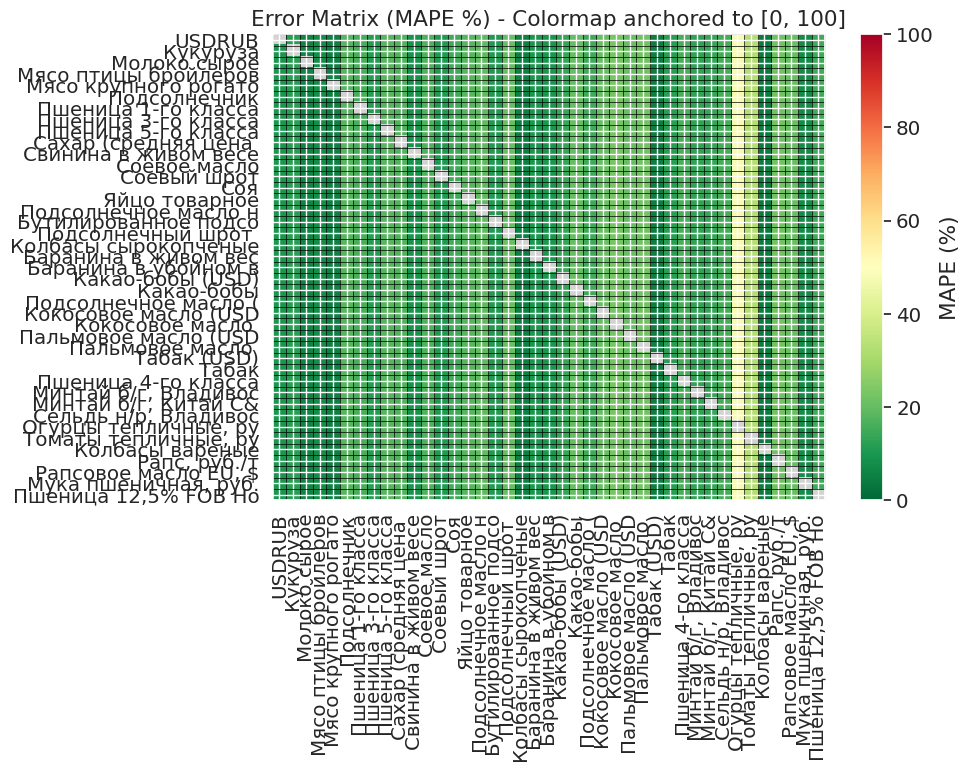

In [94]:
plot_error_matrix(final_matrix)

### Naive


--- Plotting Prediction ---
Training data ends on: 2023-01-01
Conditioning on 'Мясо крупного рогатого скота в живом весе ' 12 months into the future.
Actual value of 'Мясо крупного рогатого скота в живом весе ' on 2024-01-01 is 151.65


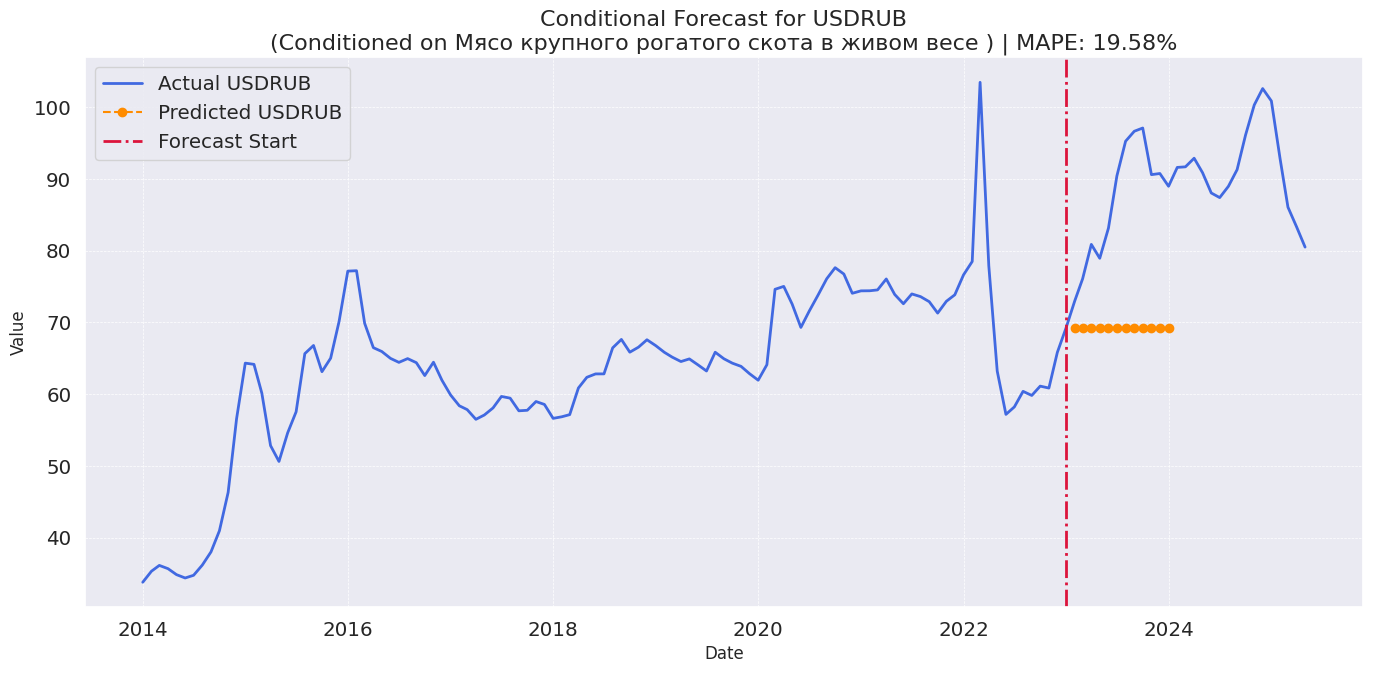

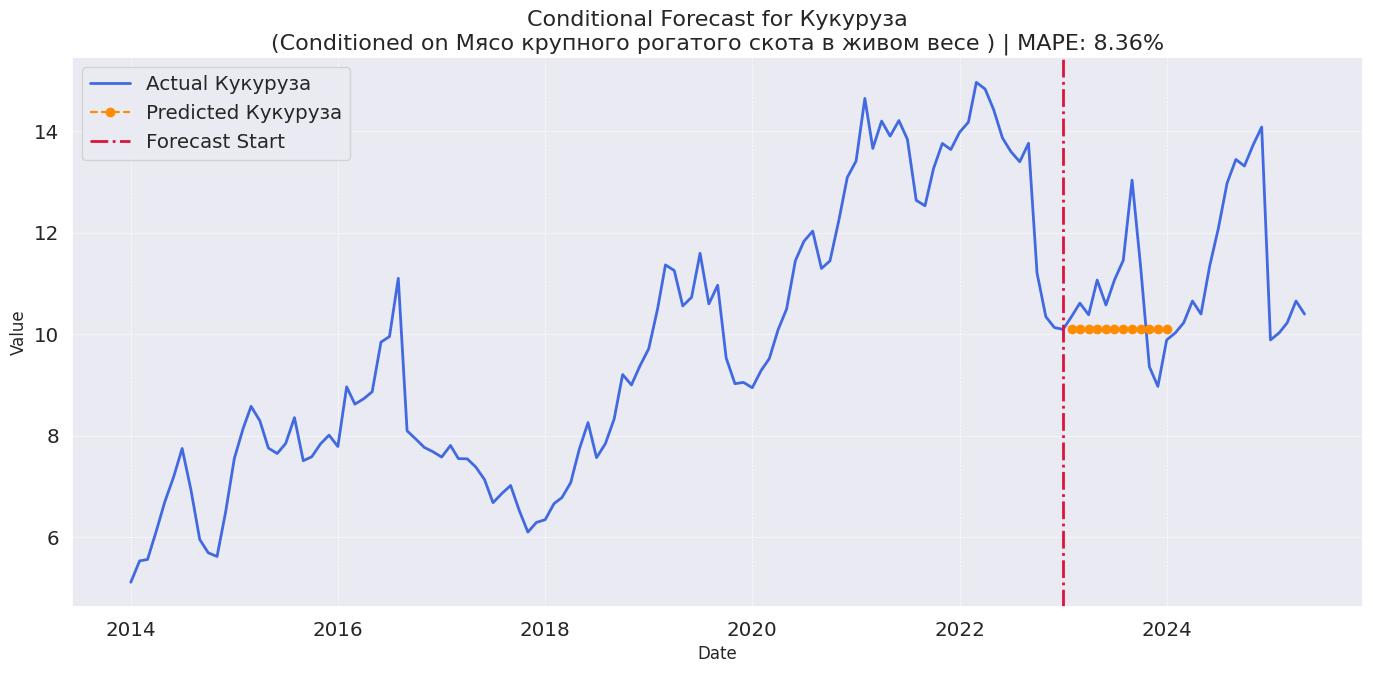

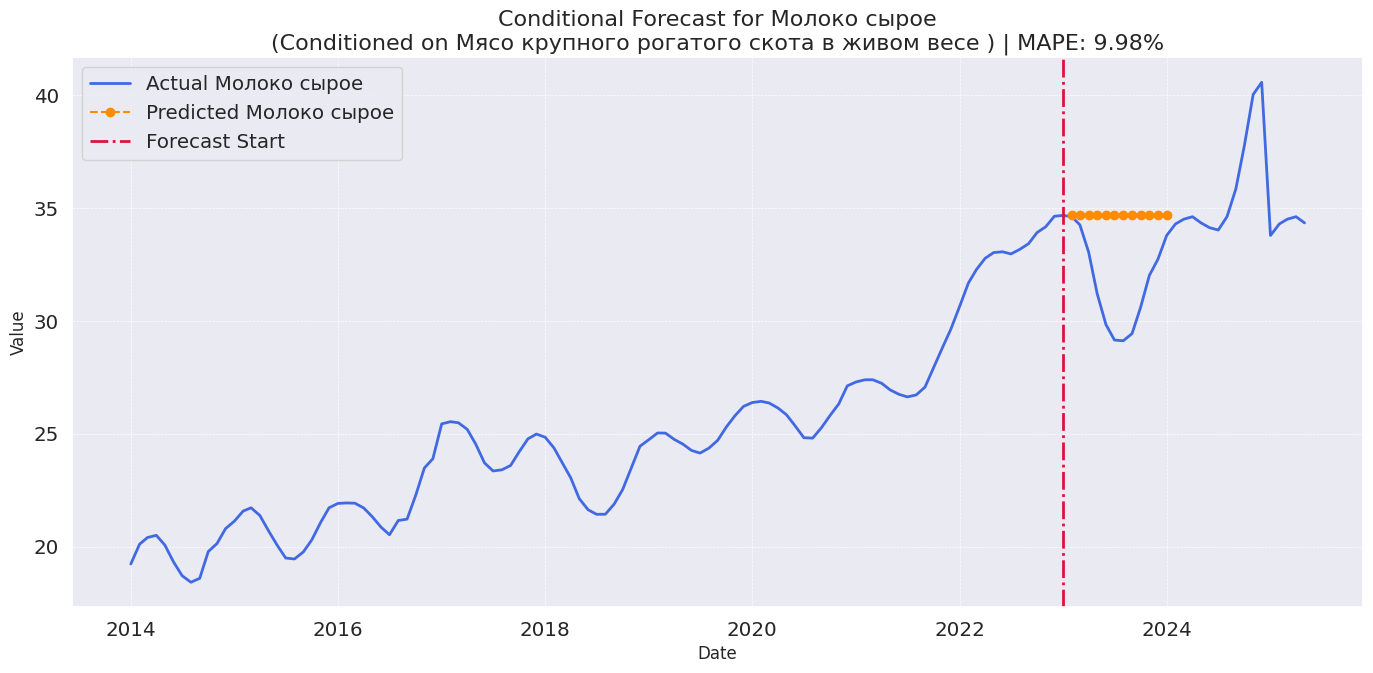

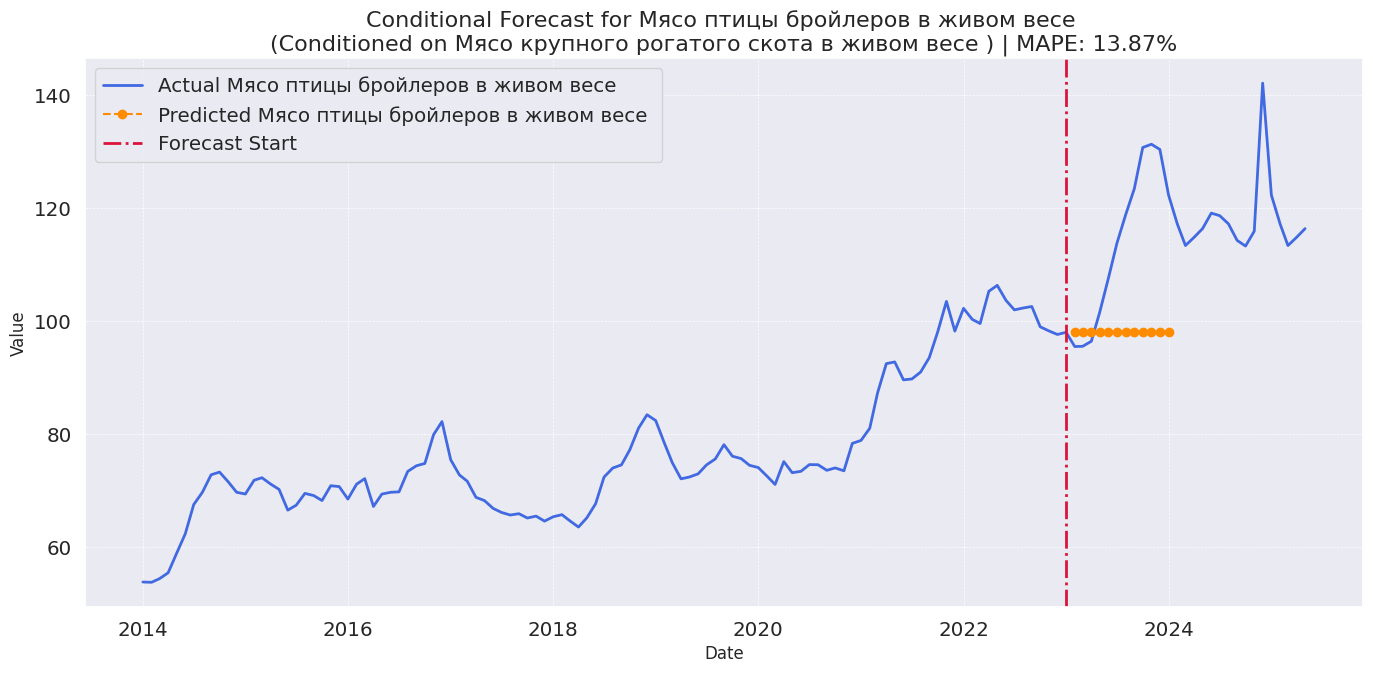

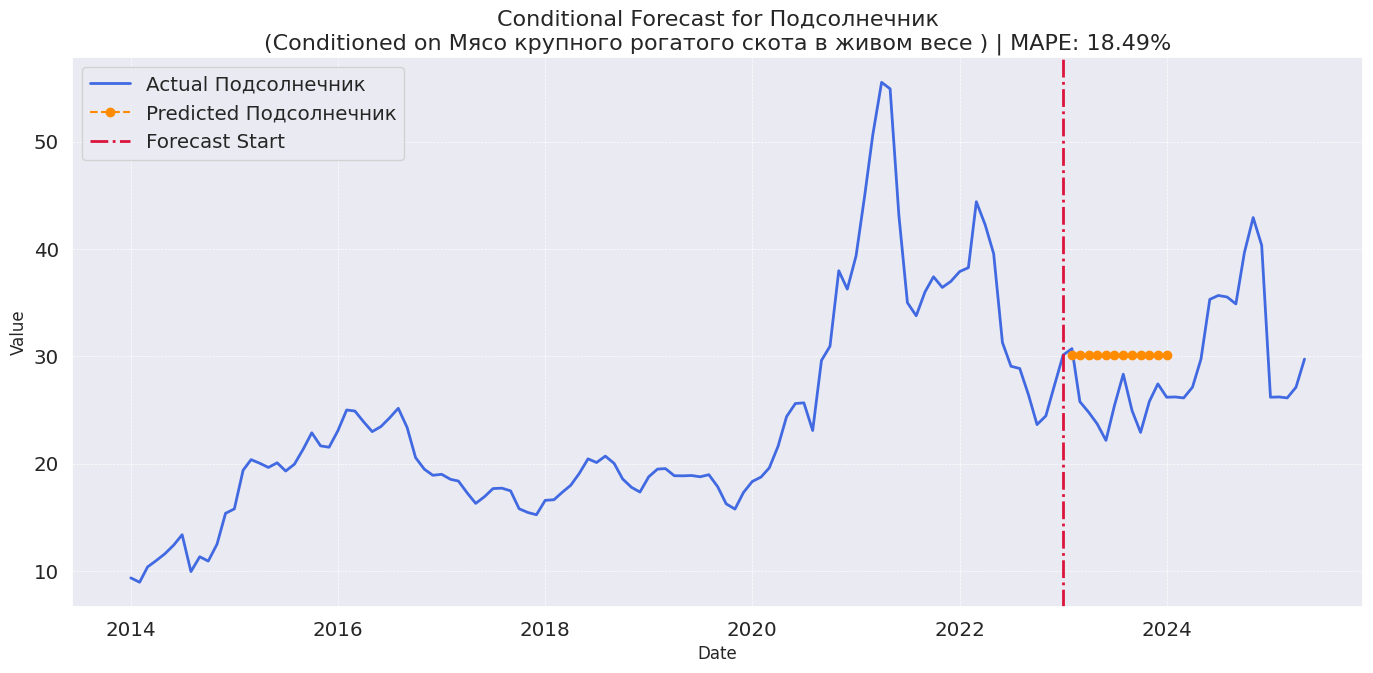

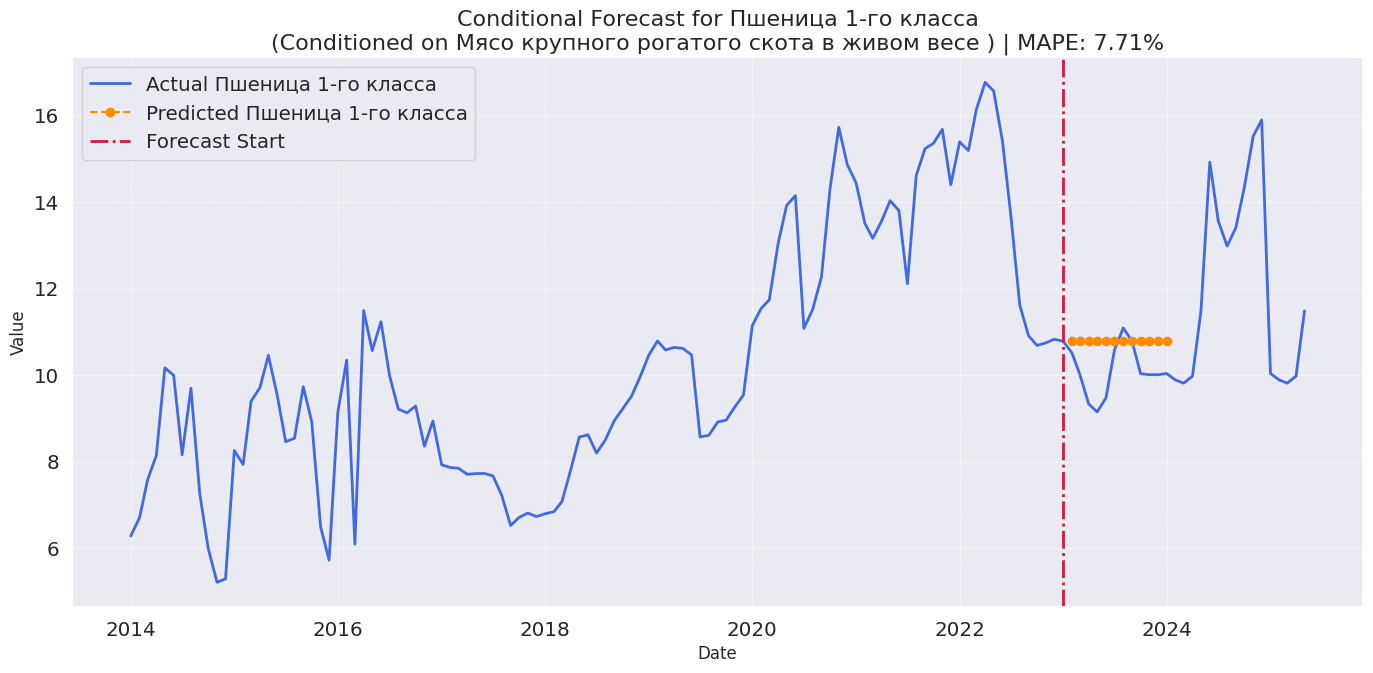

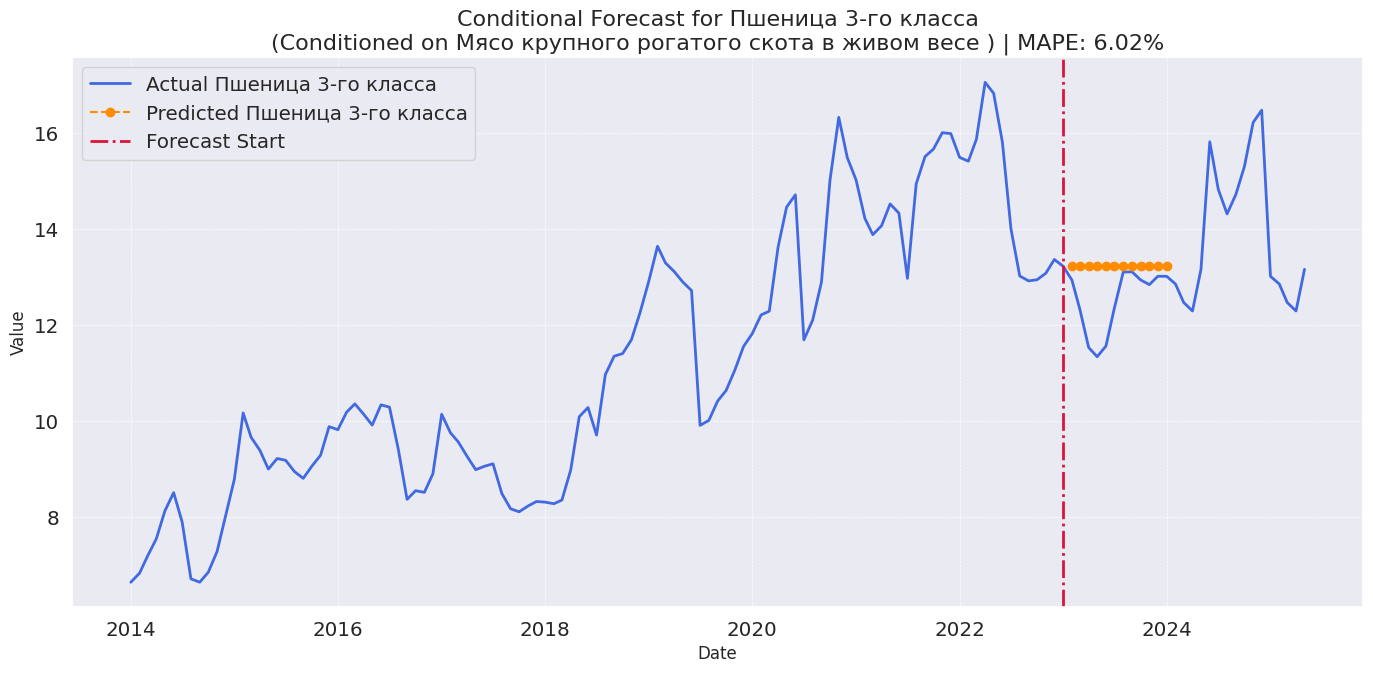

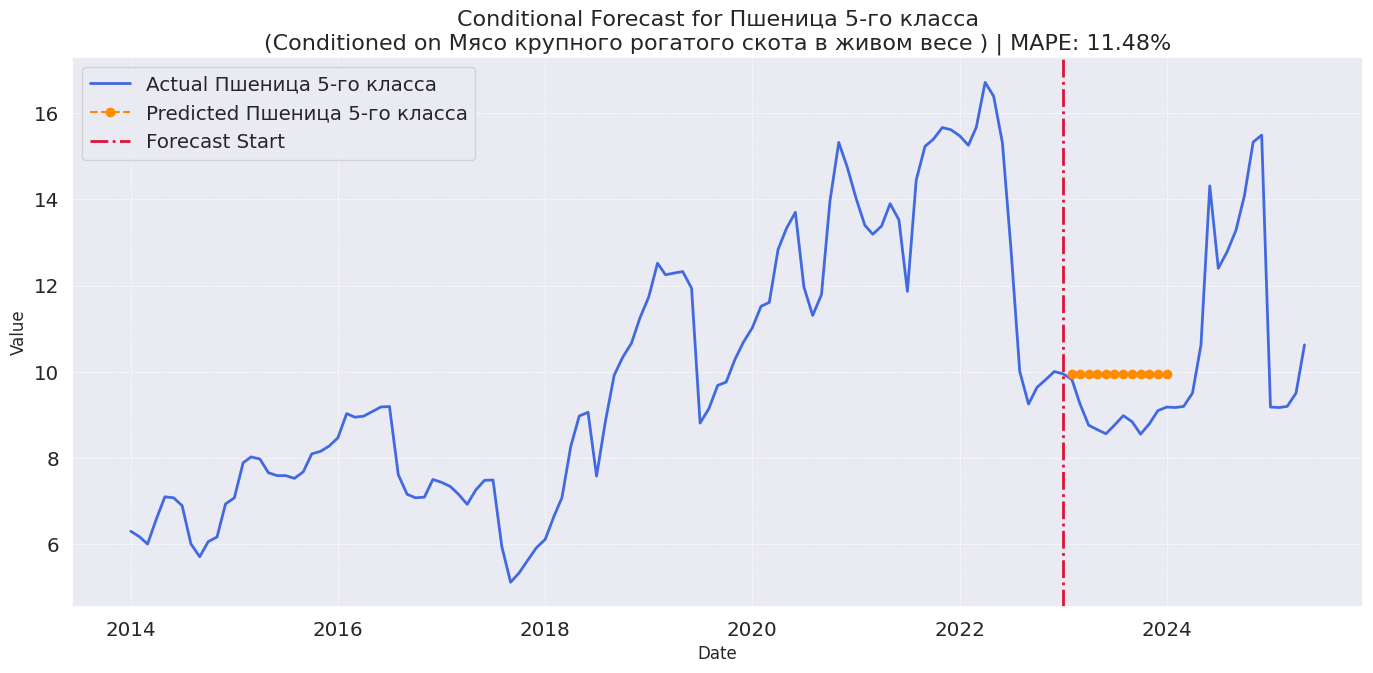

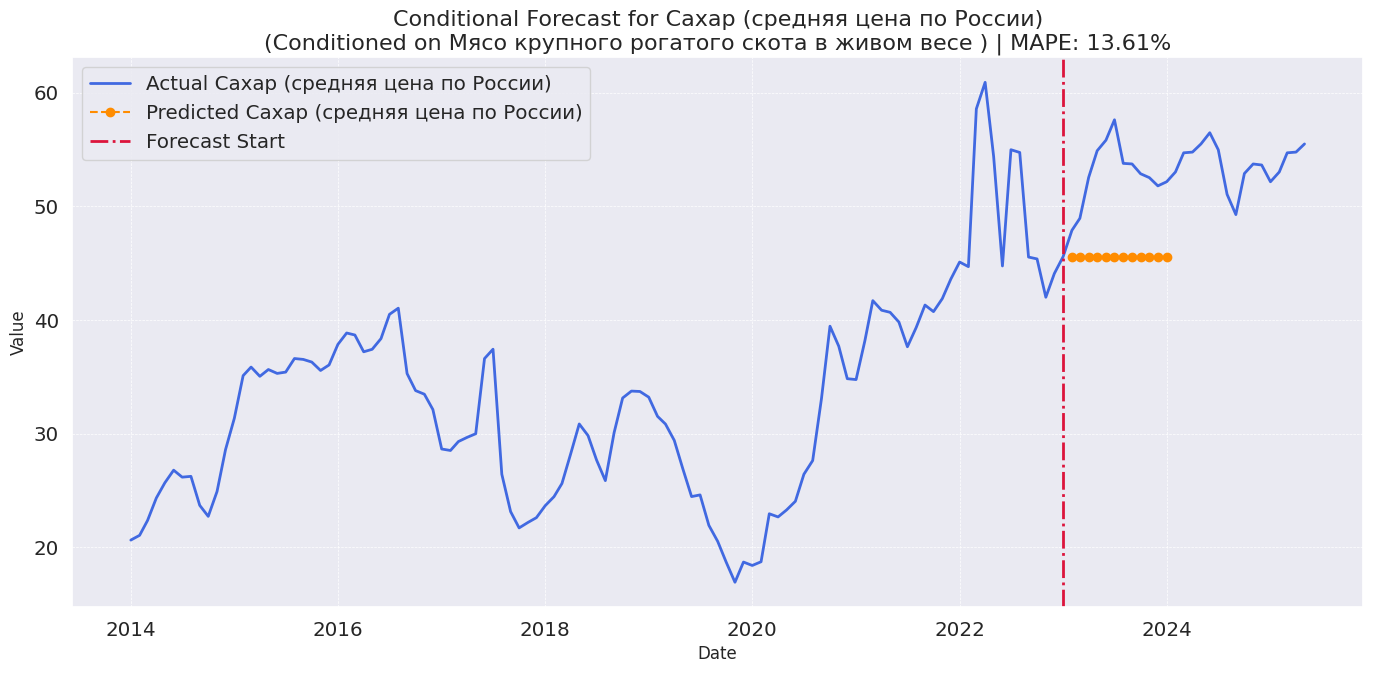

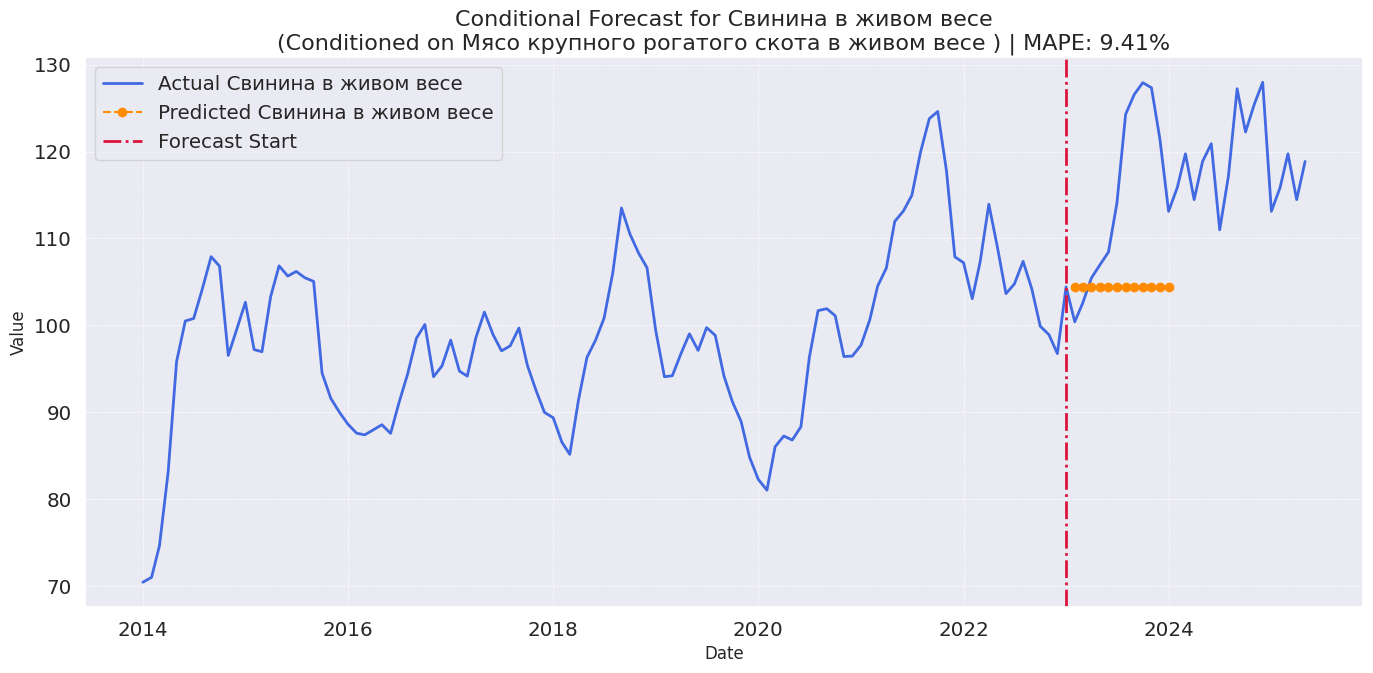

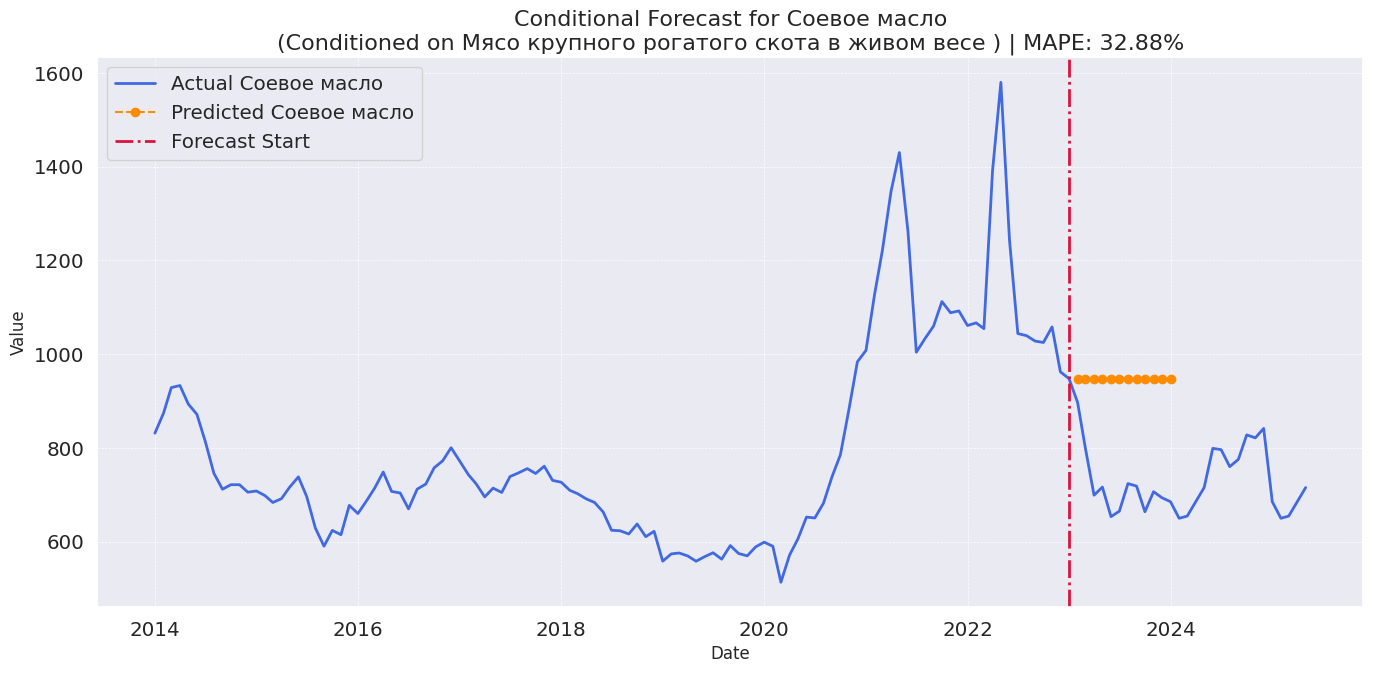

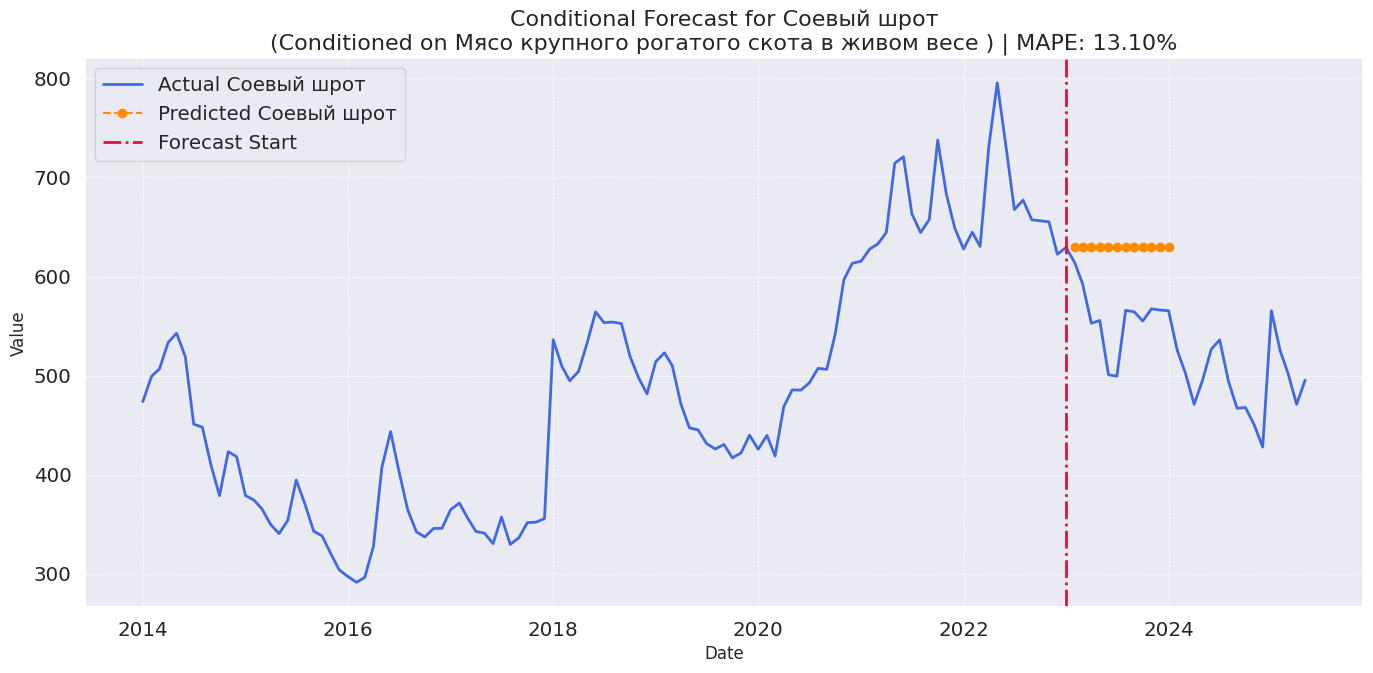

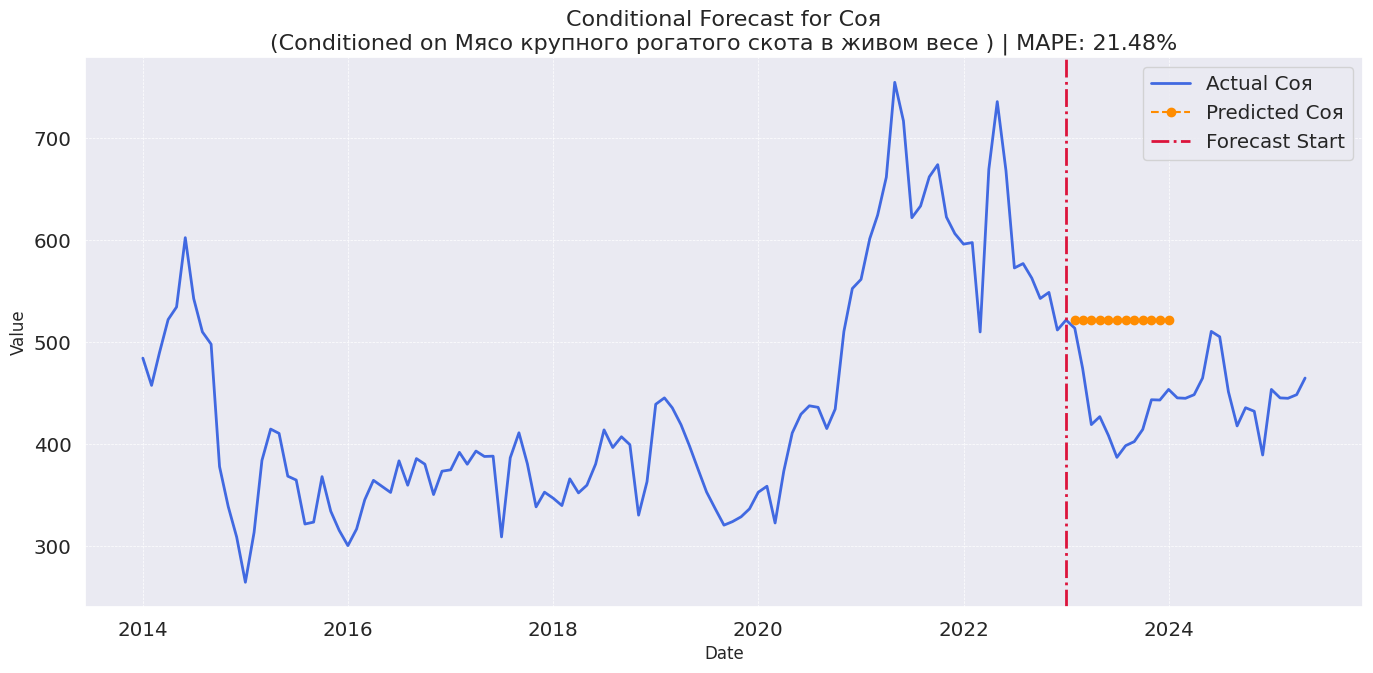

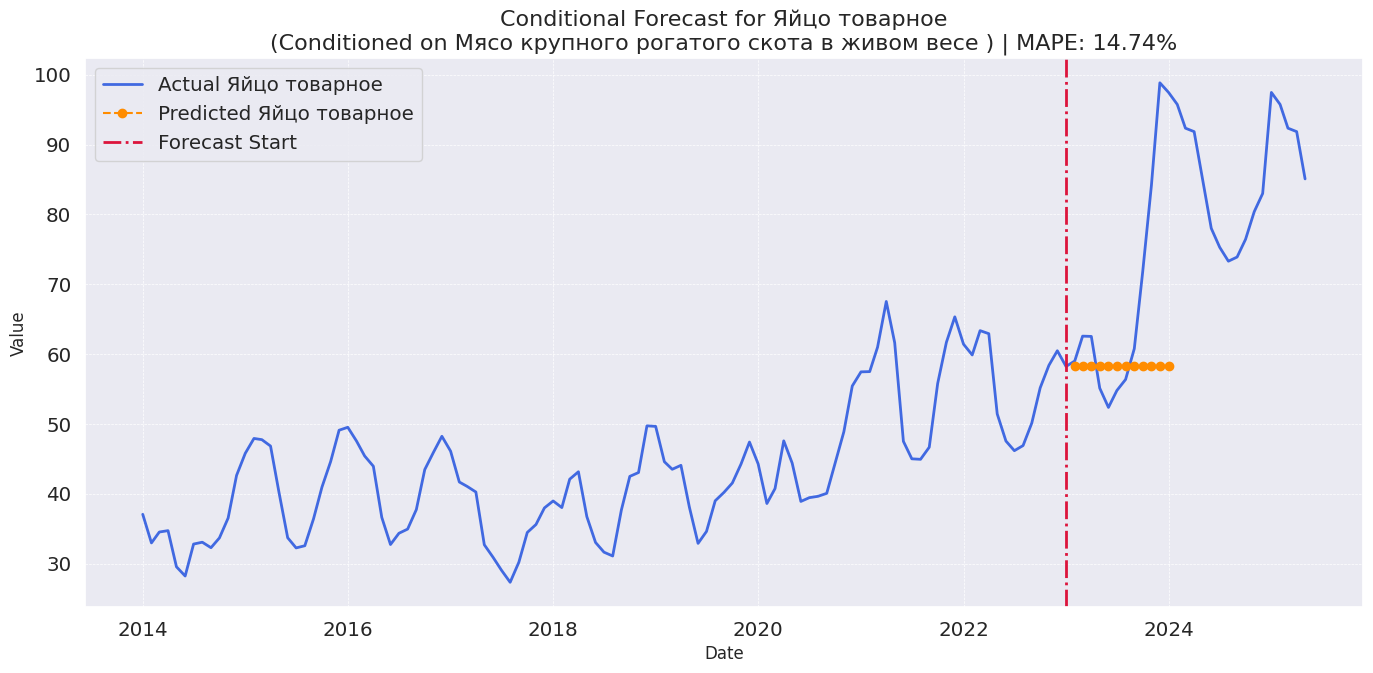

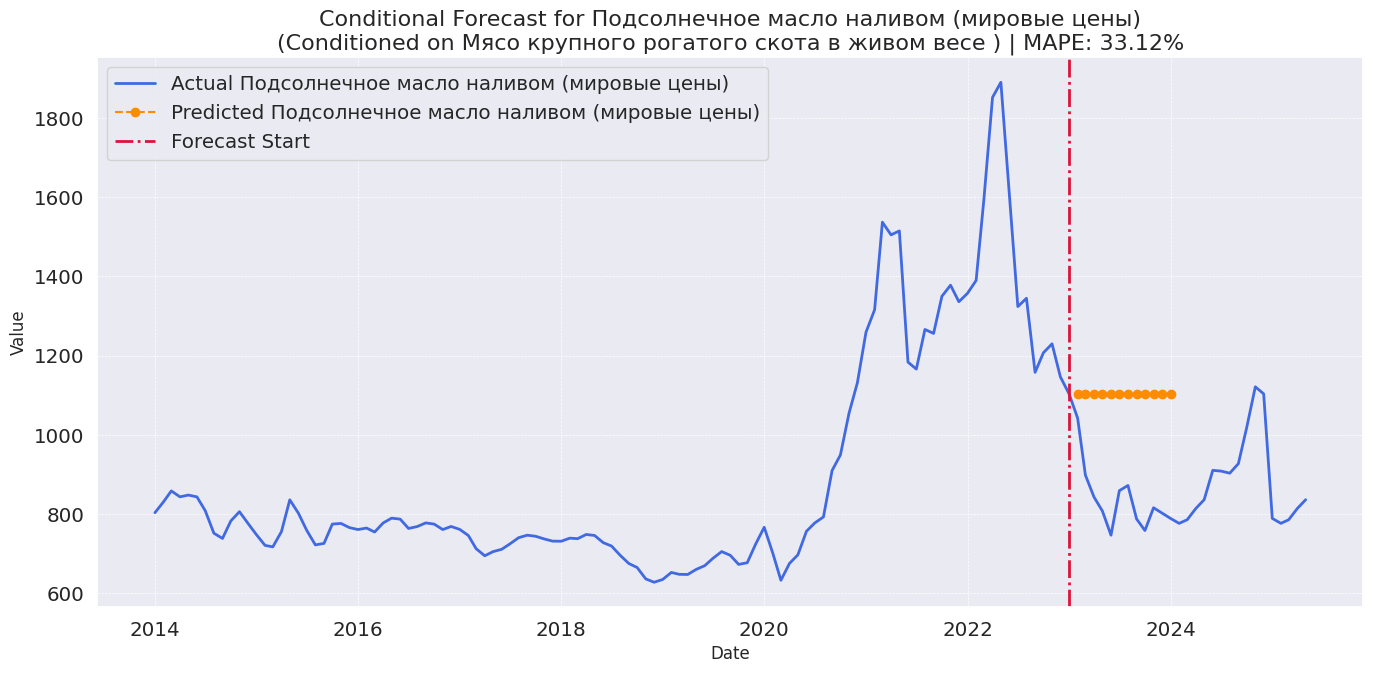

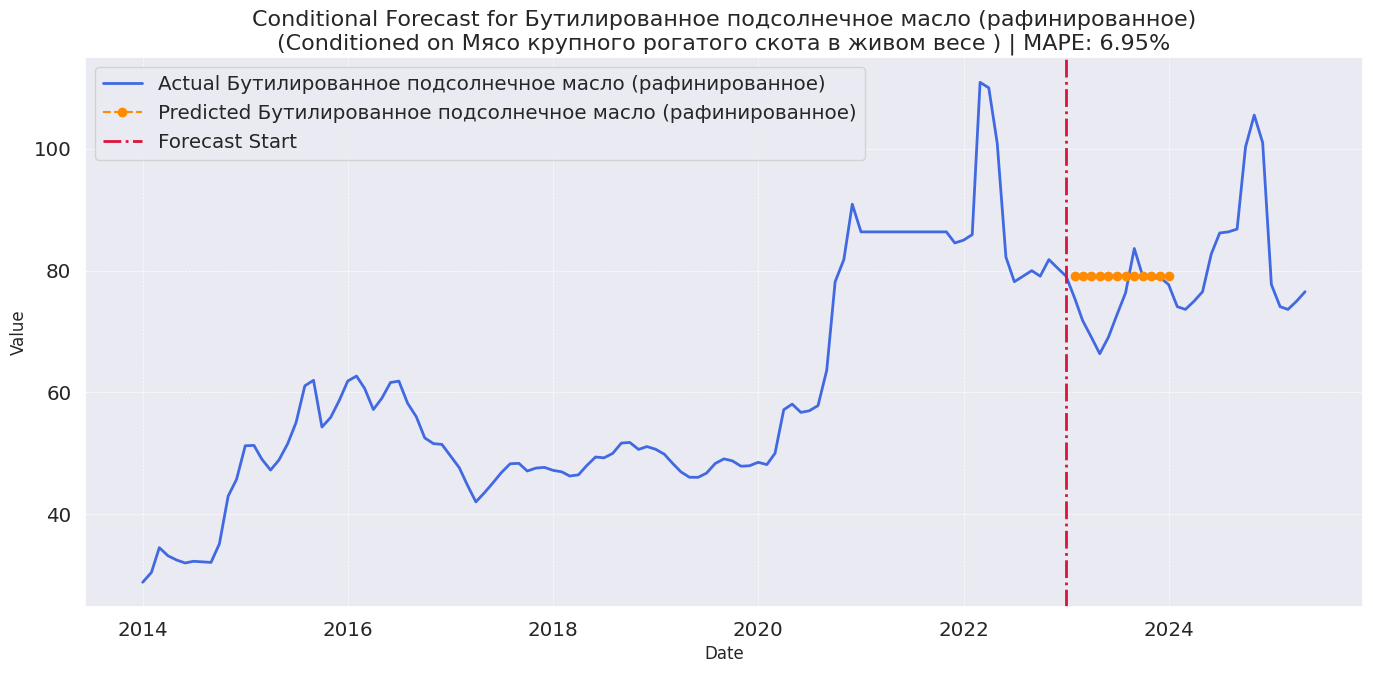

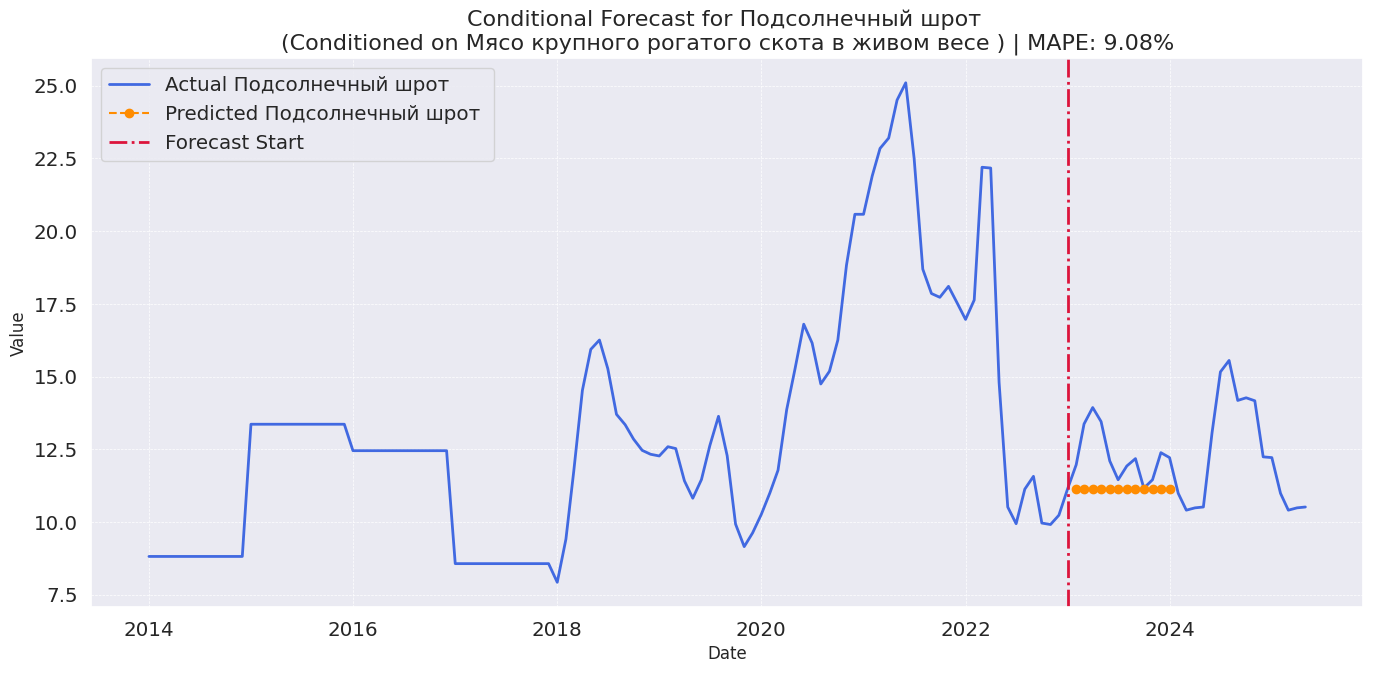

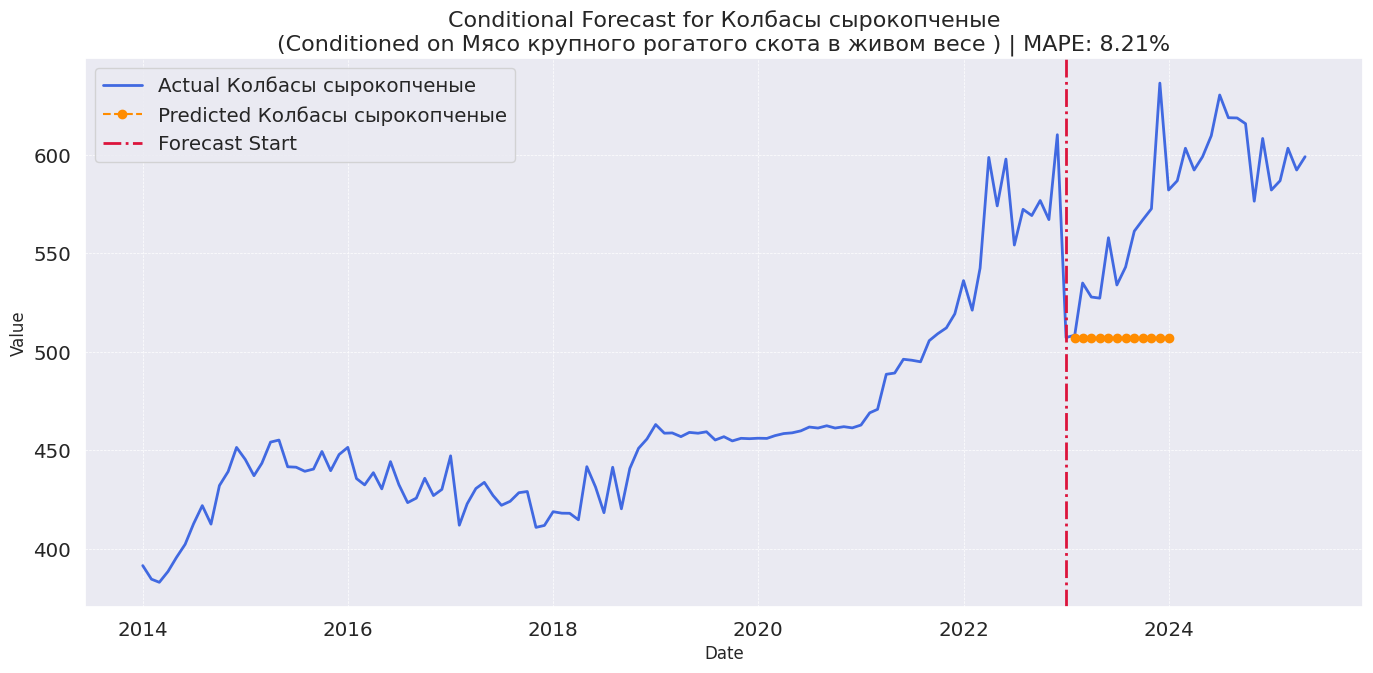

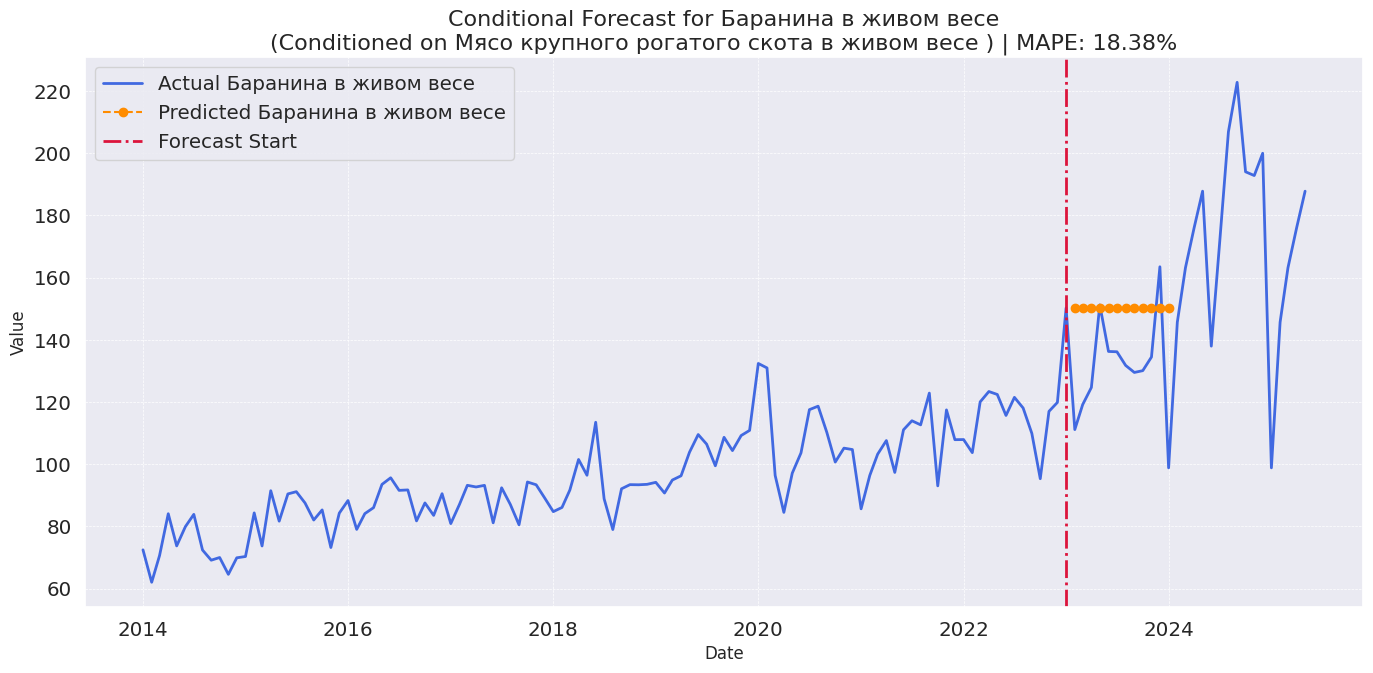

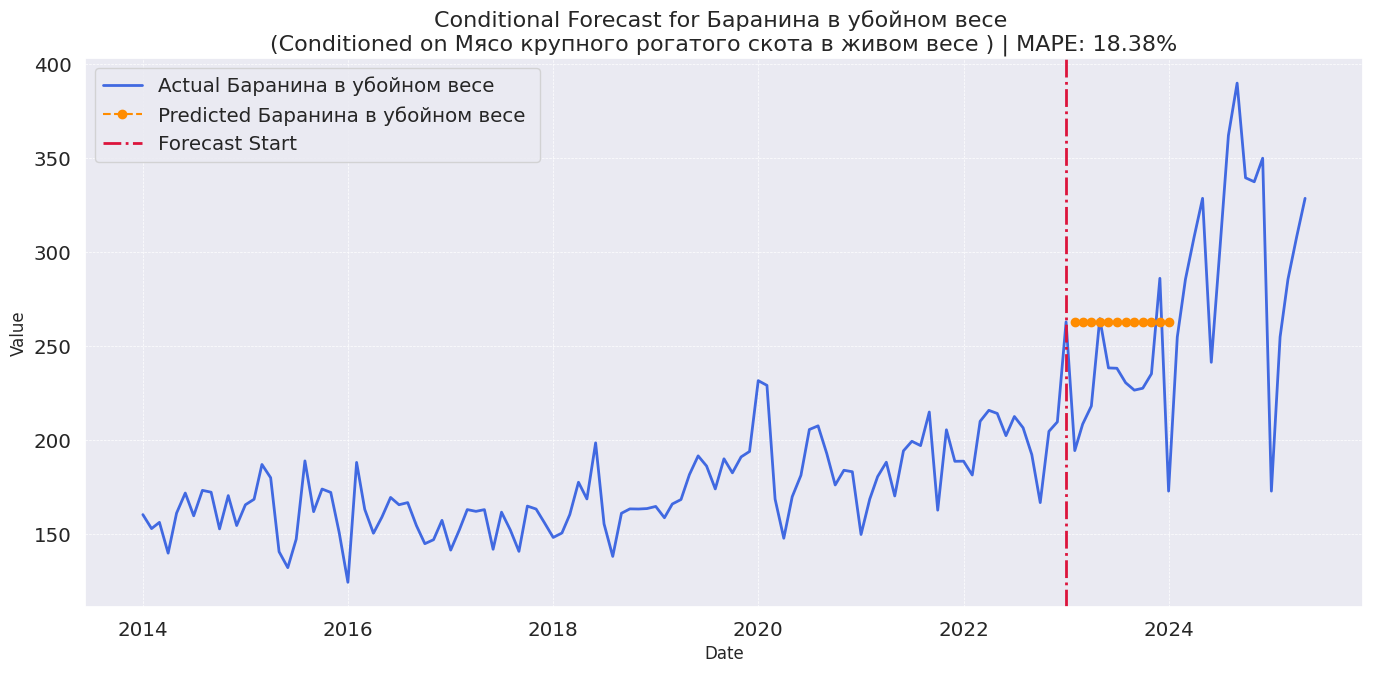

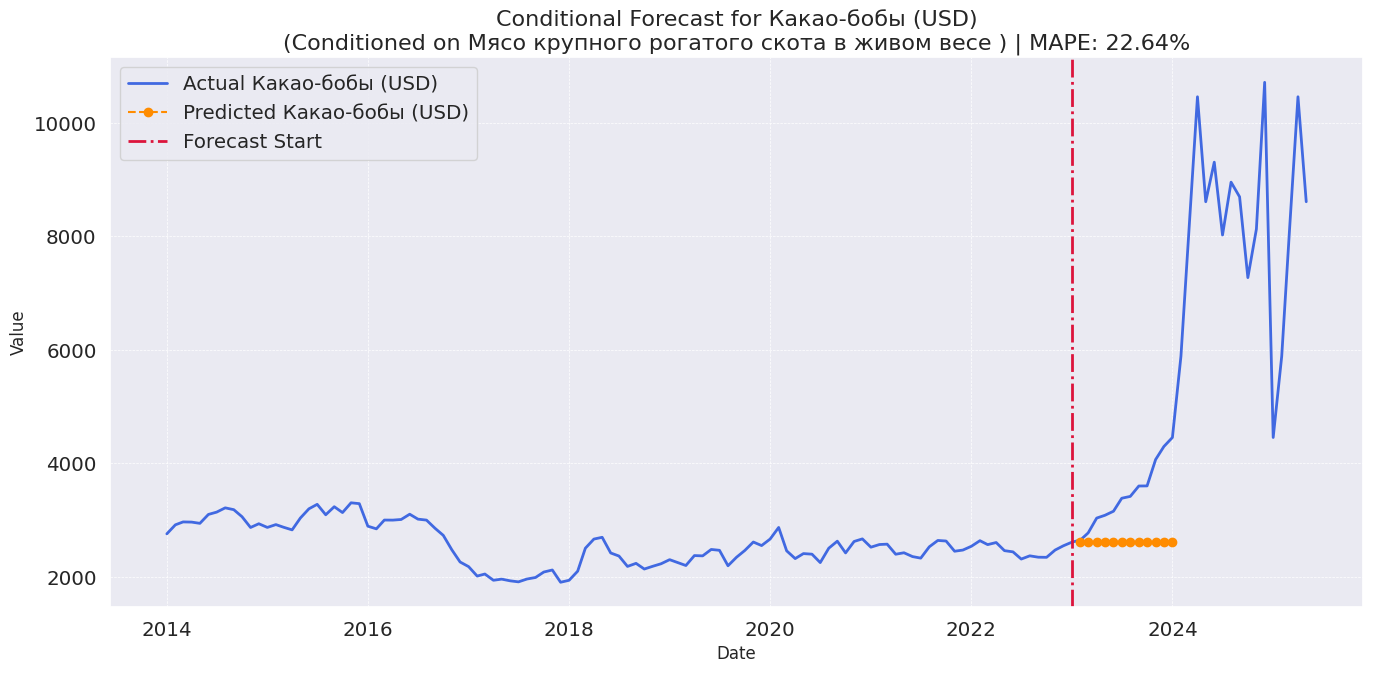

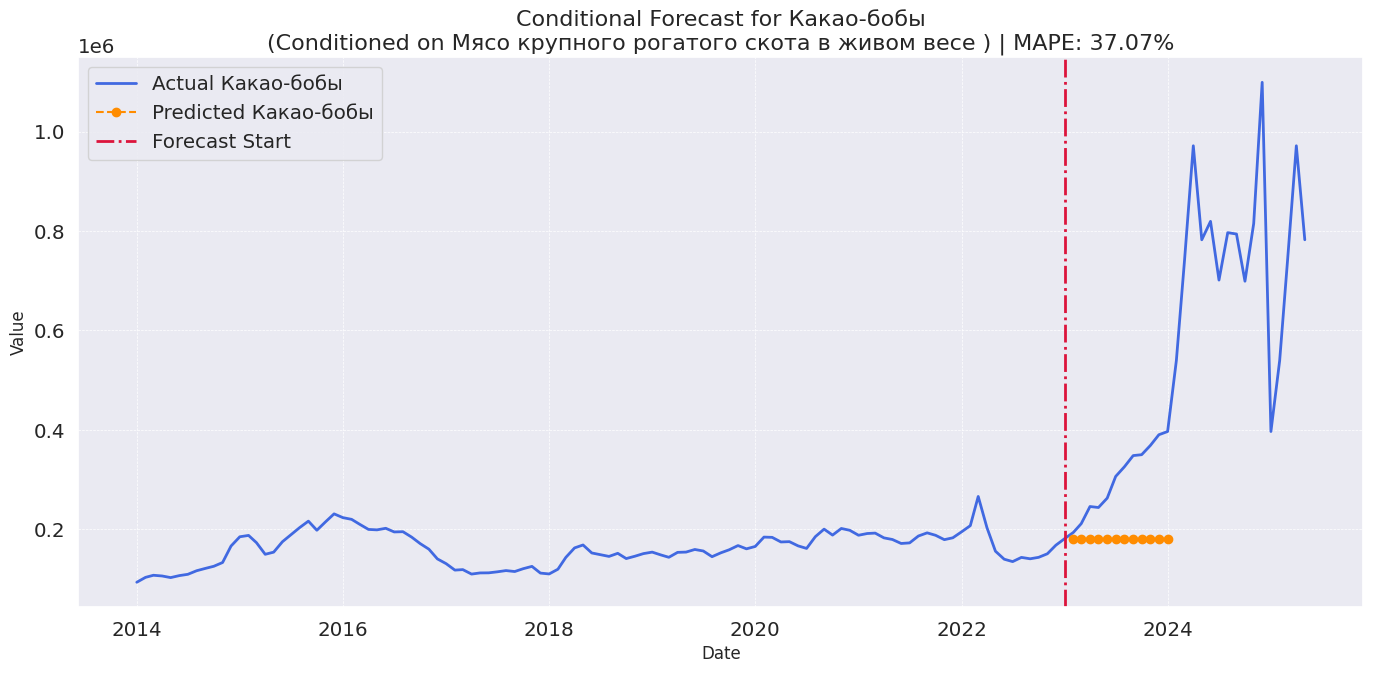

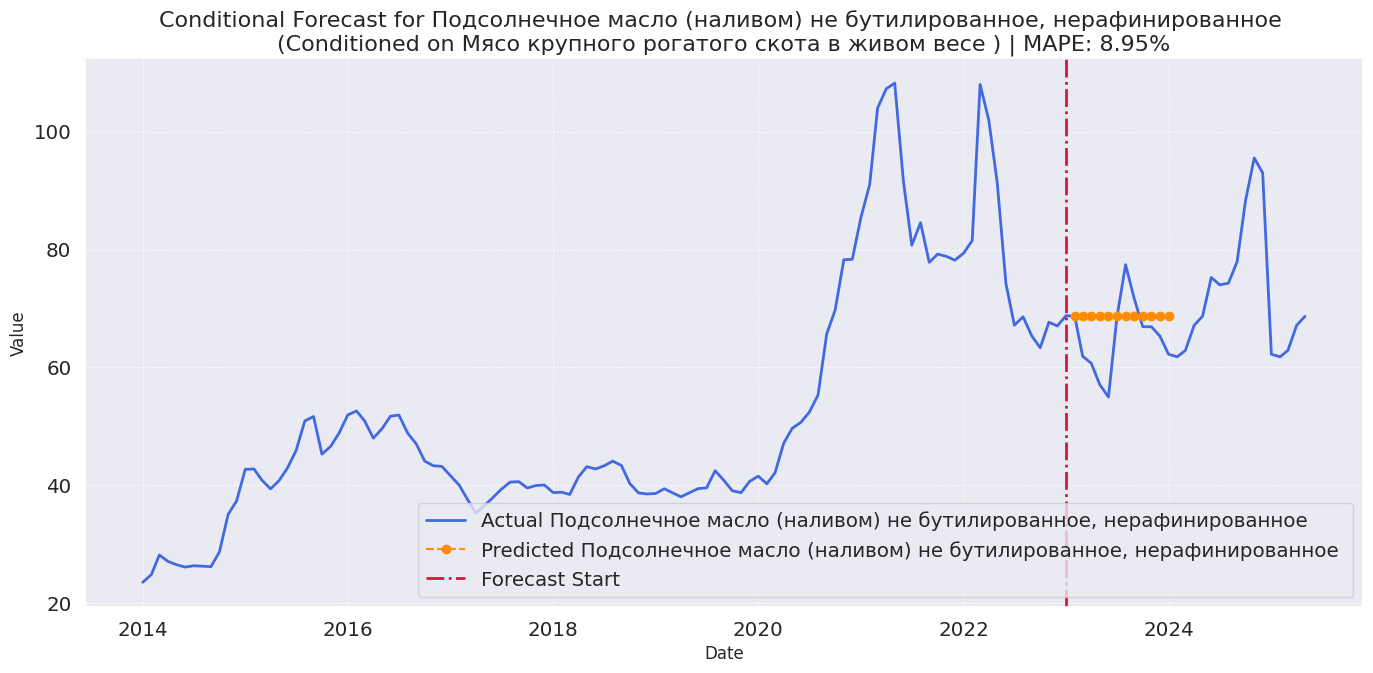

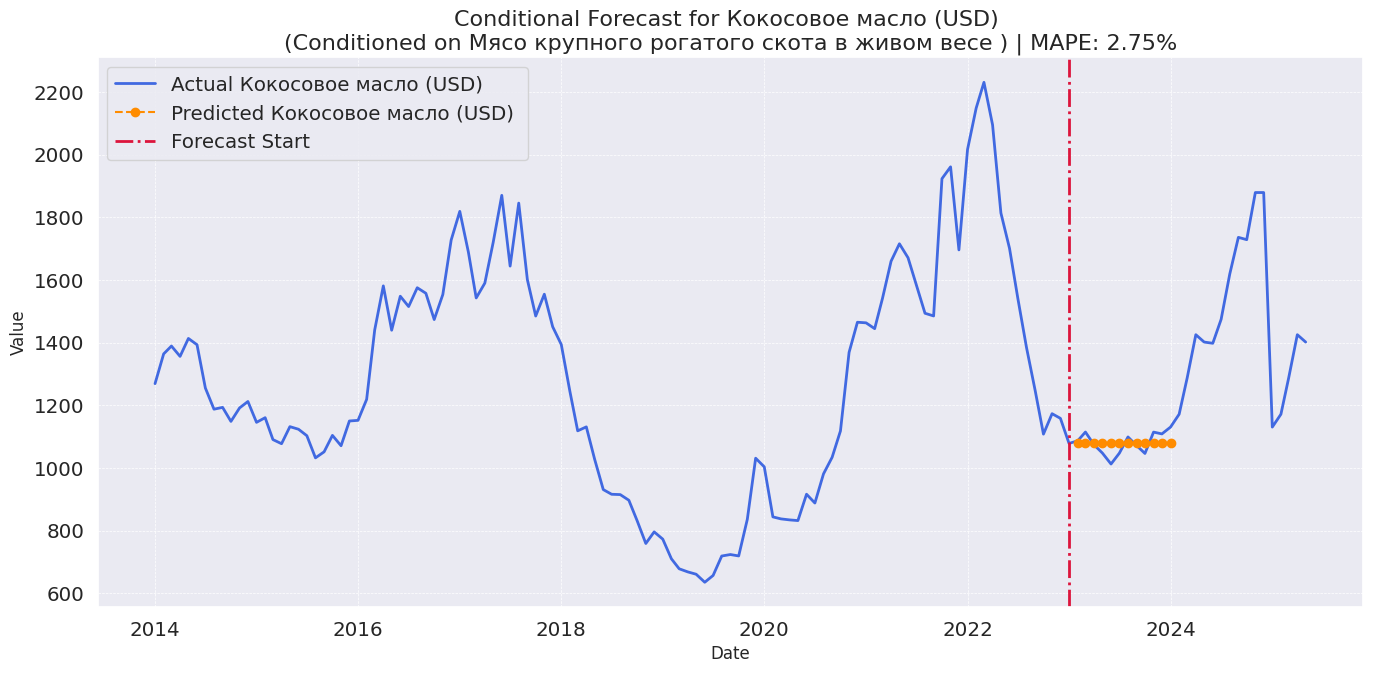

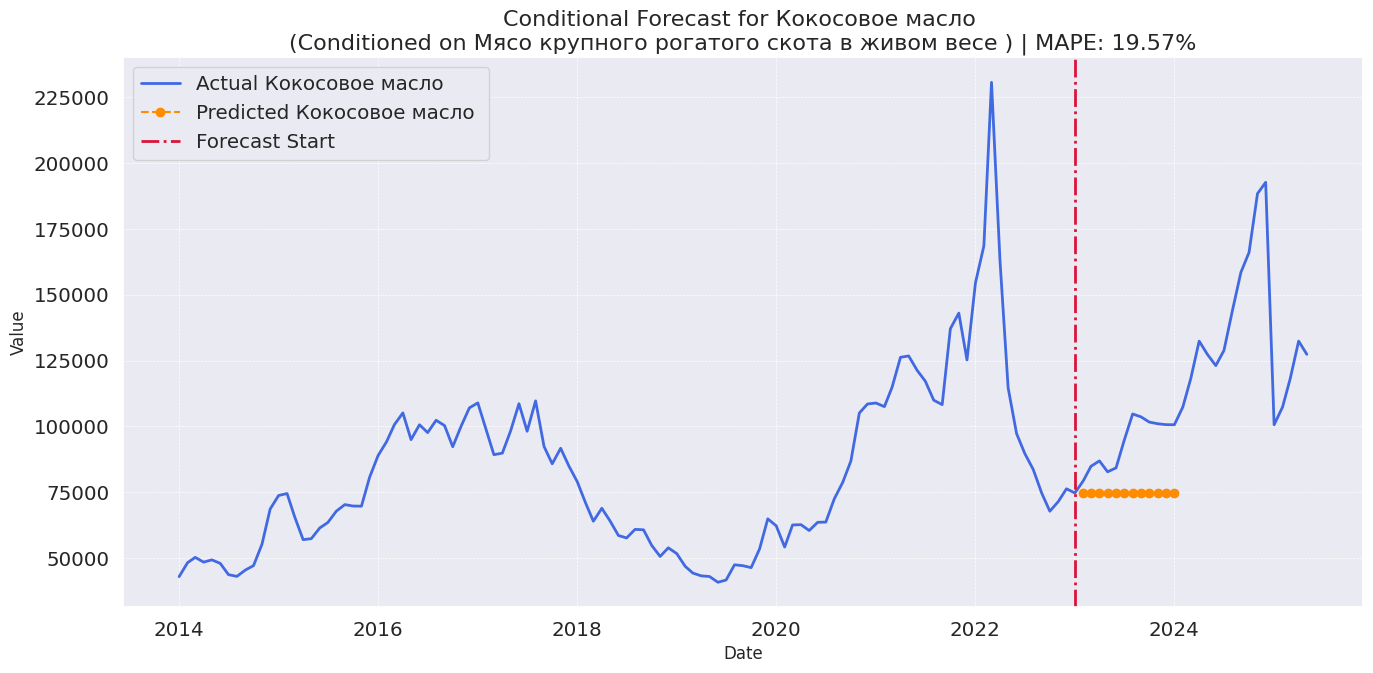

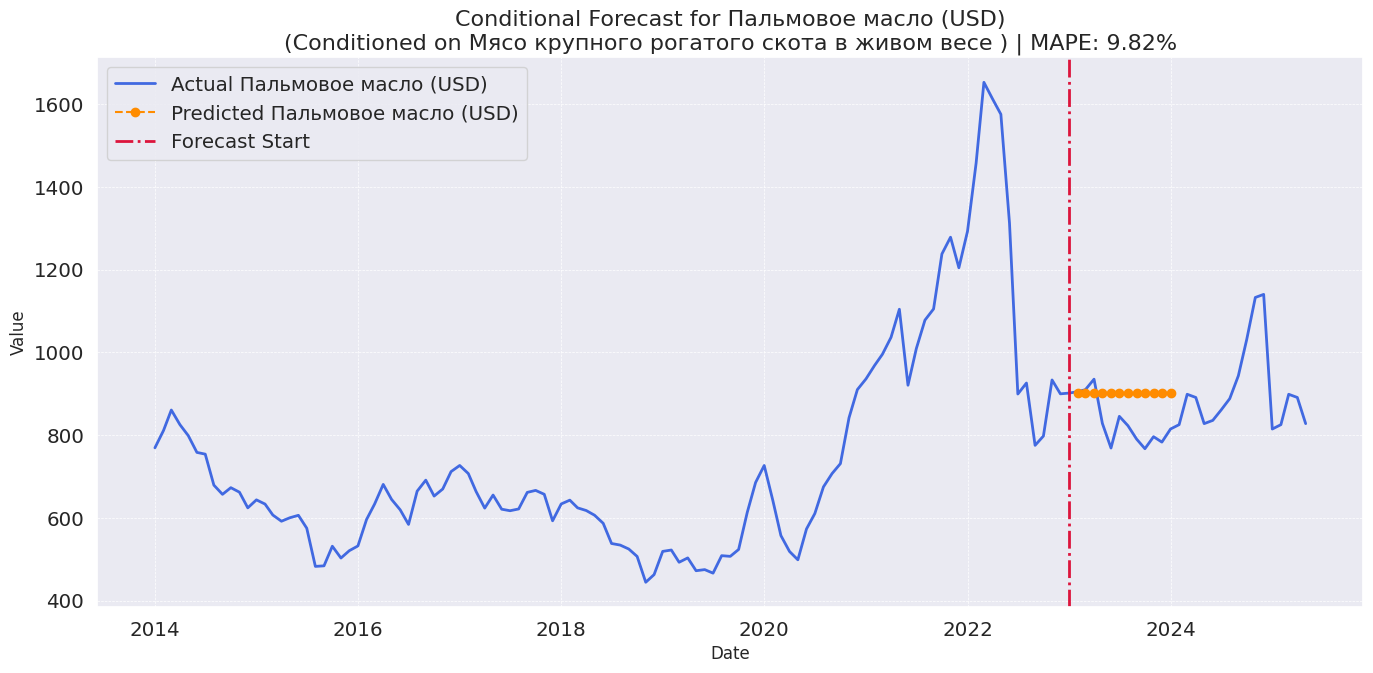

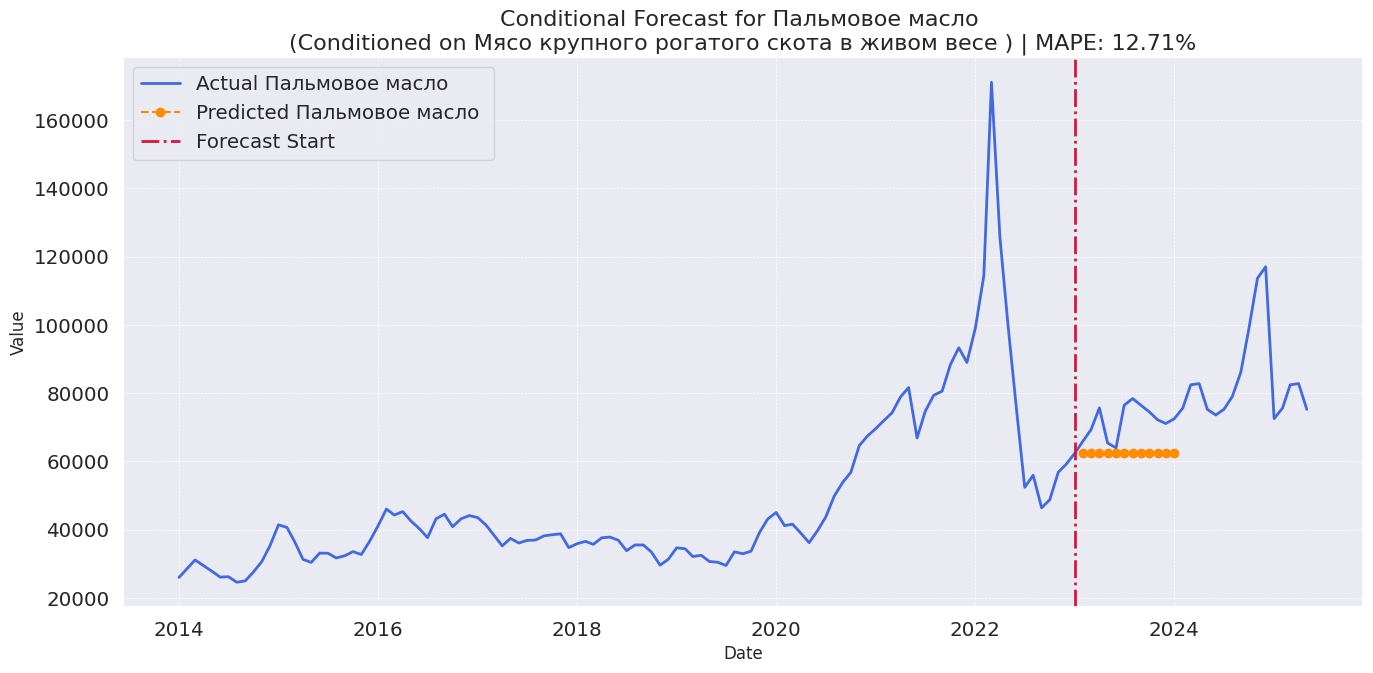

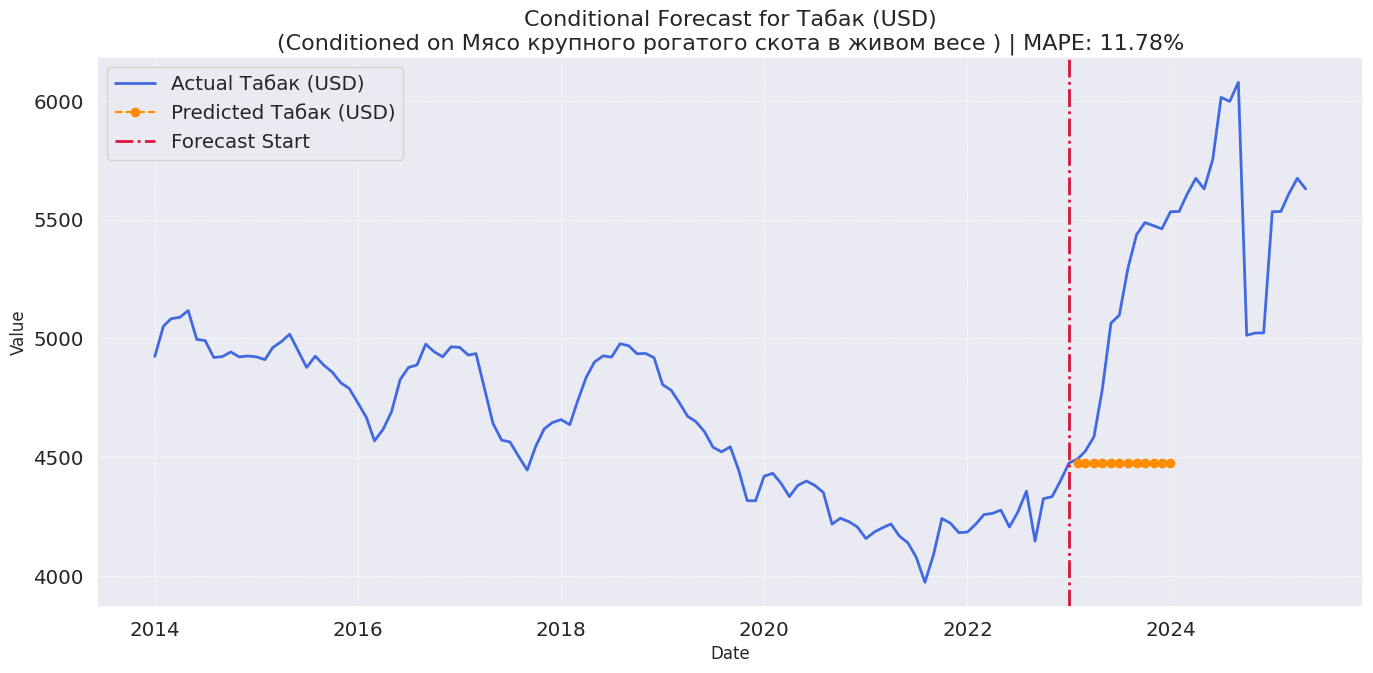

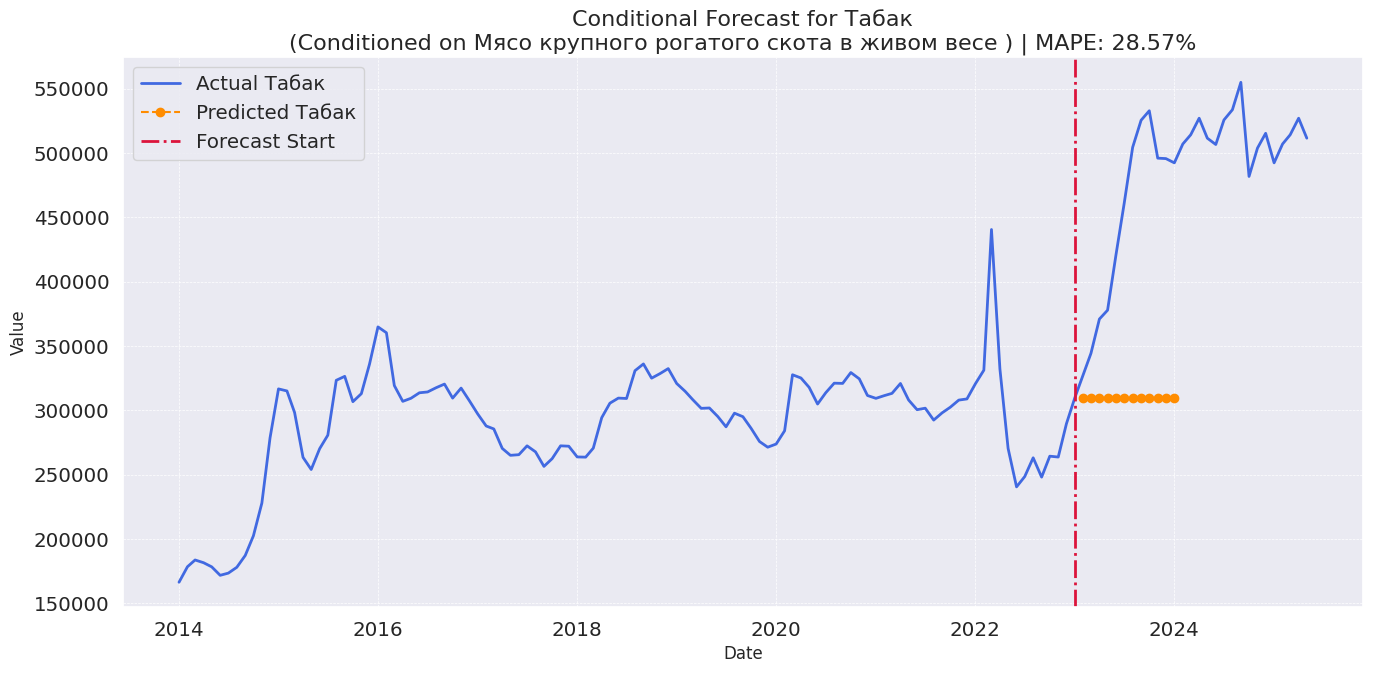

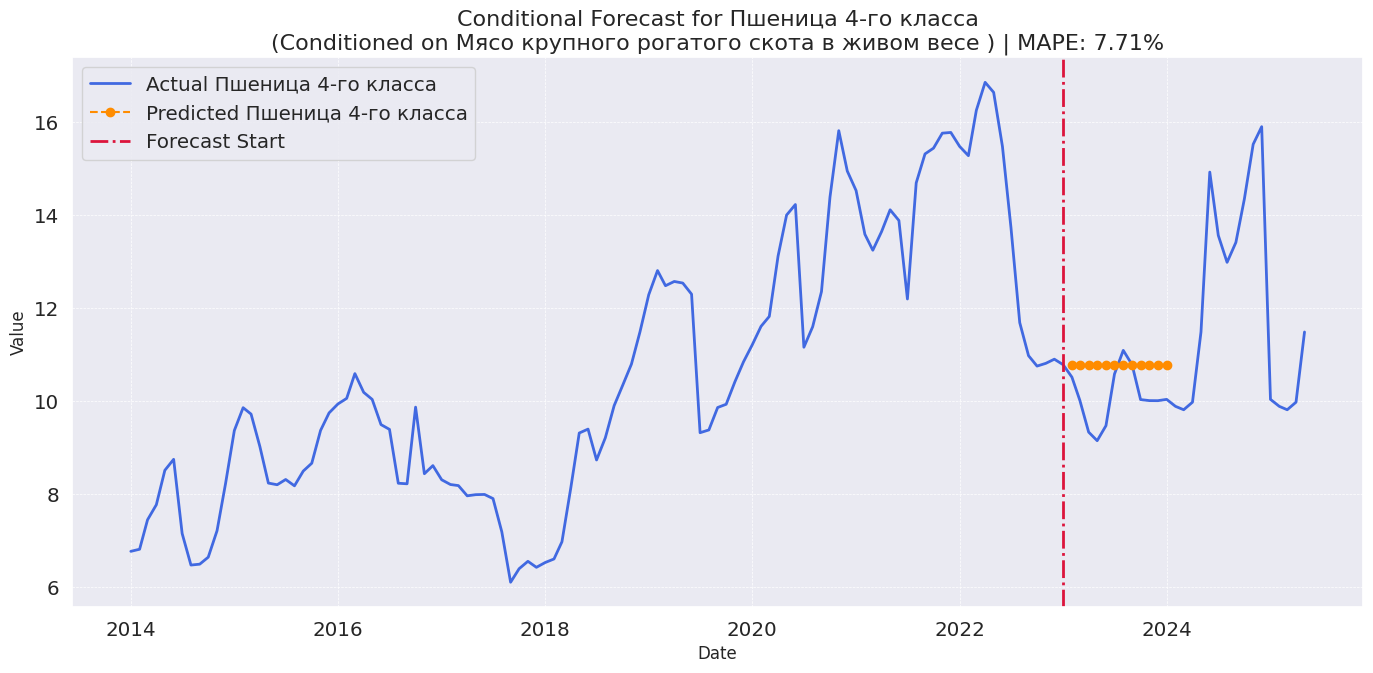

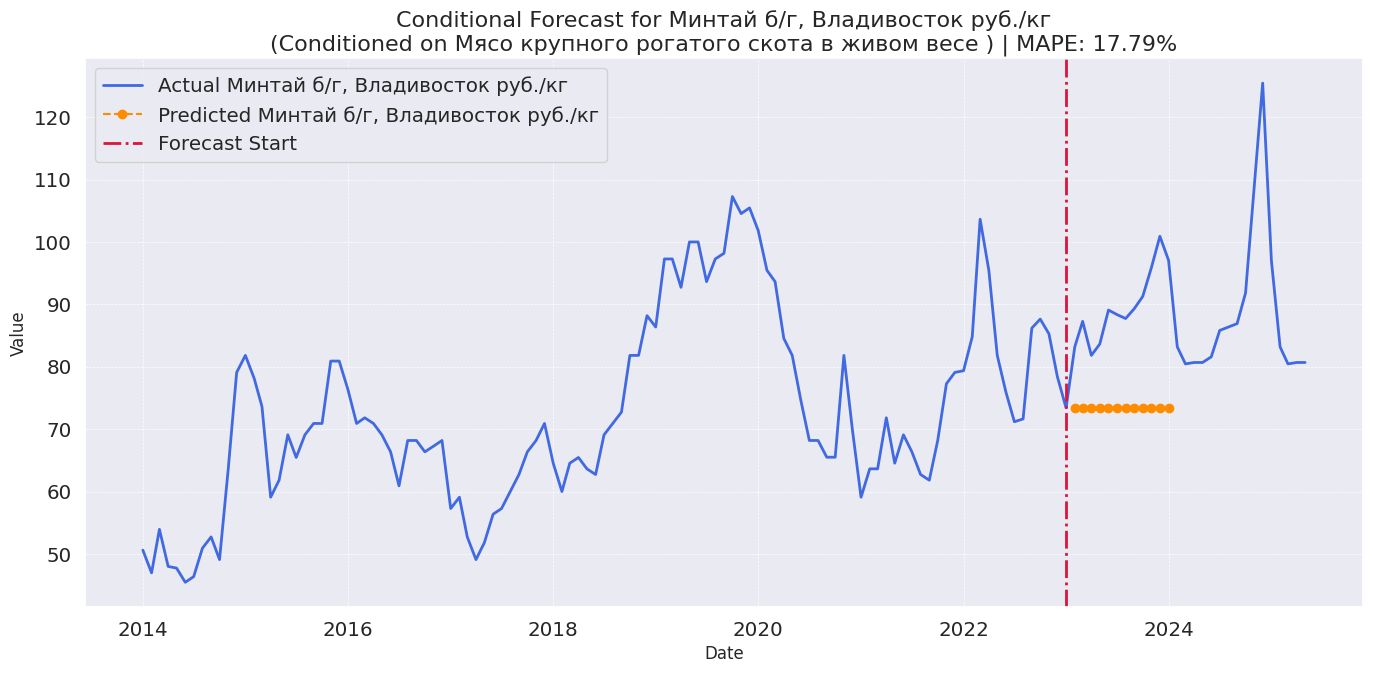

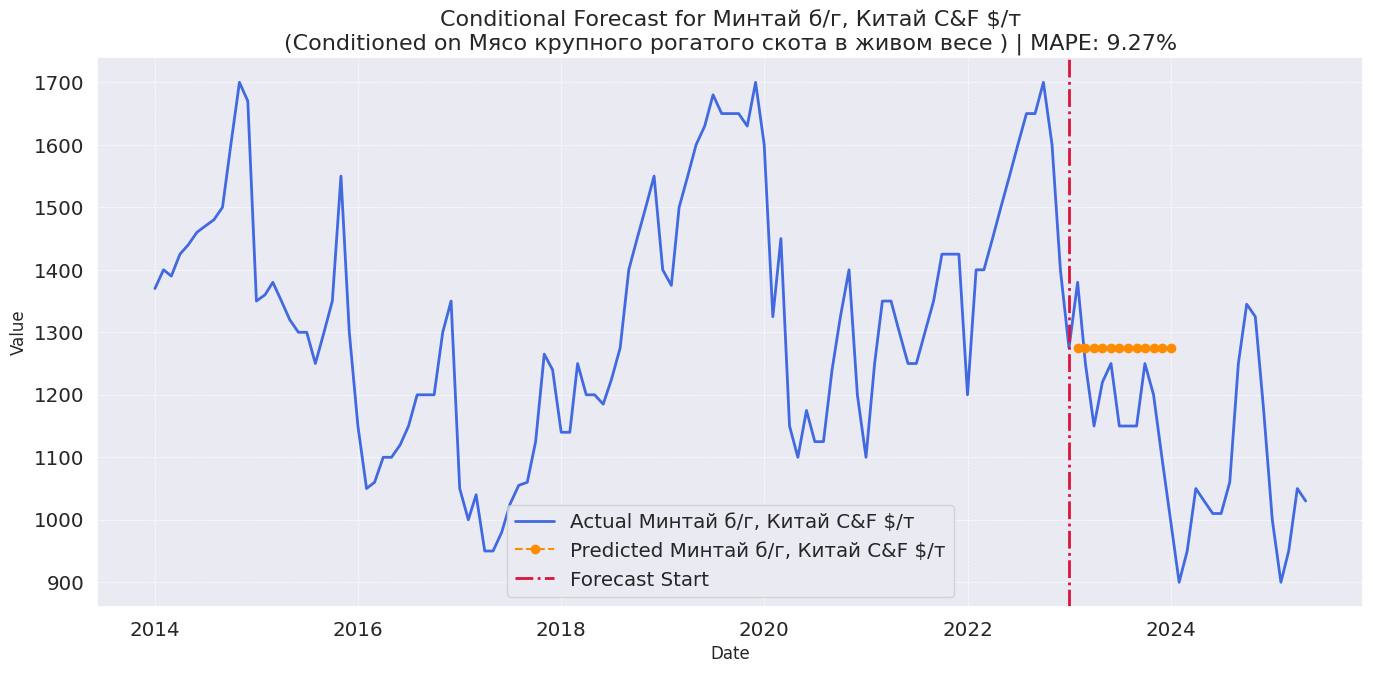

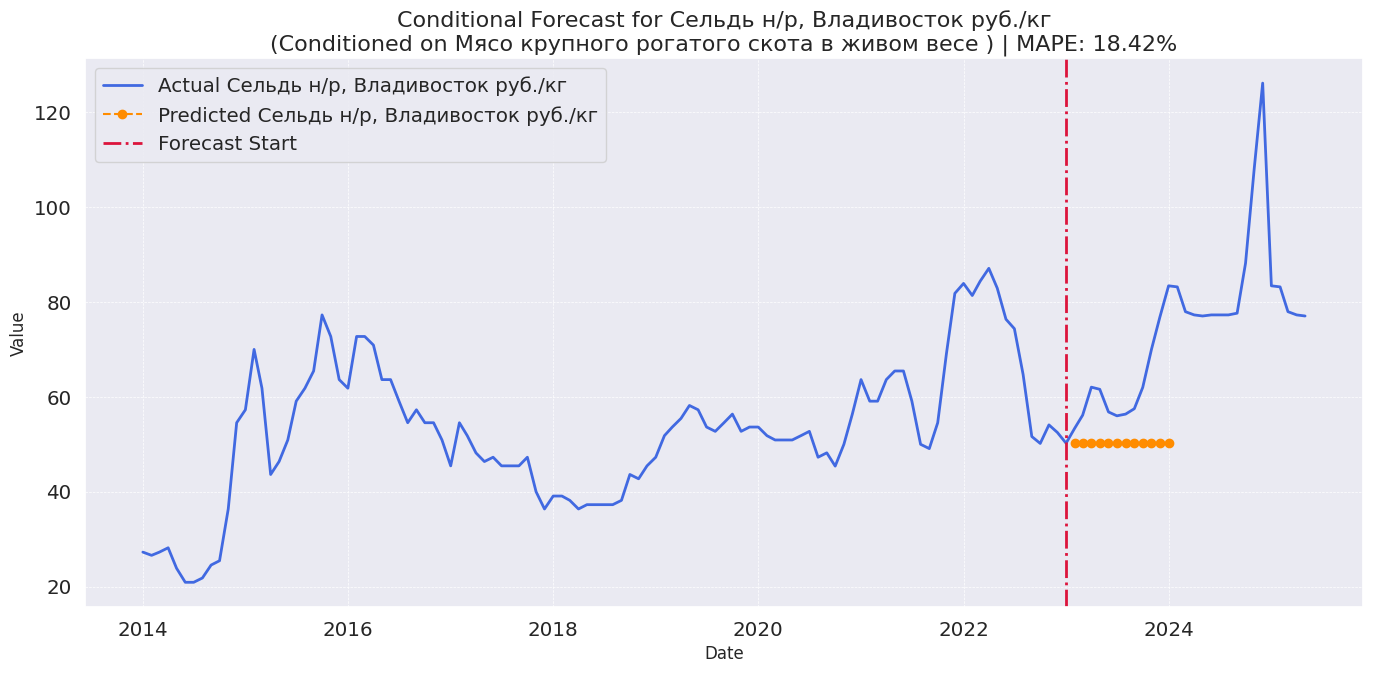

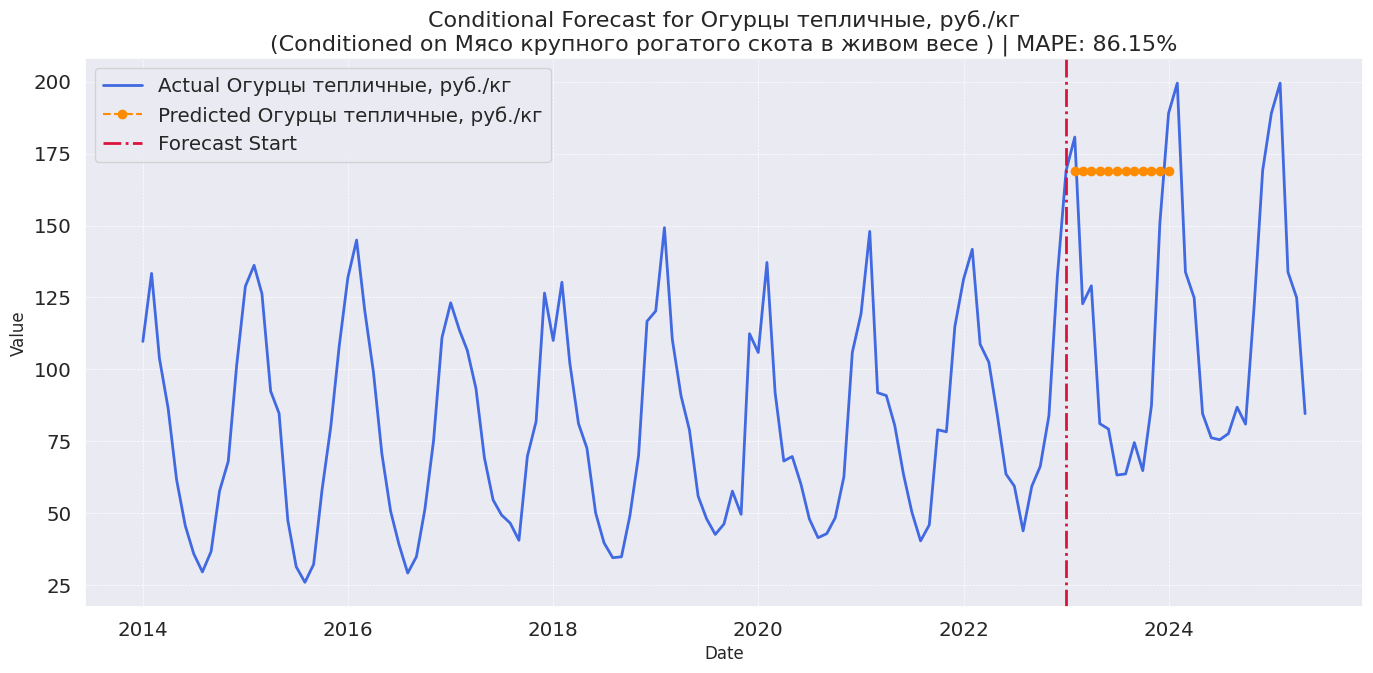

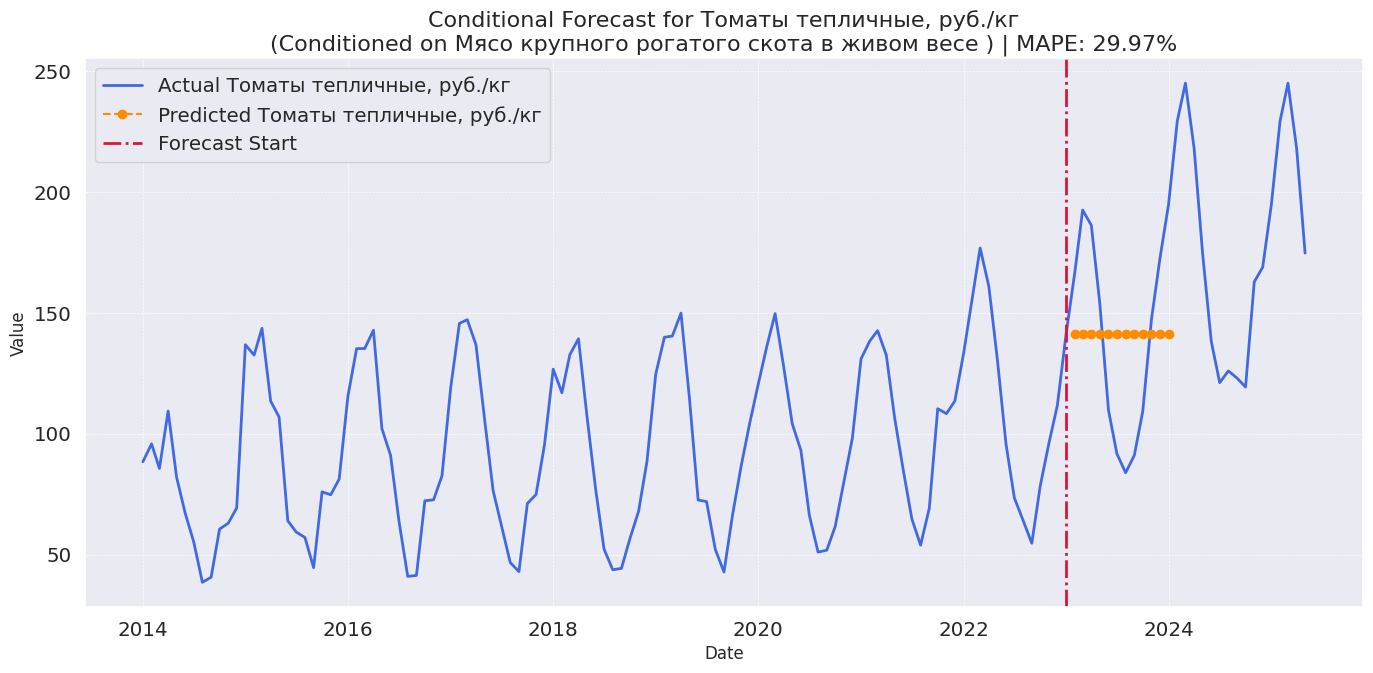

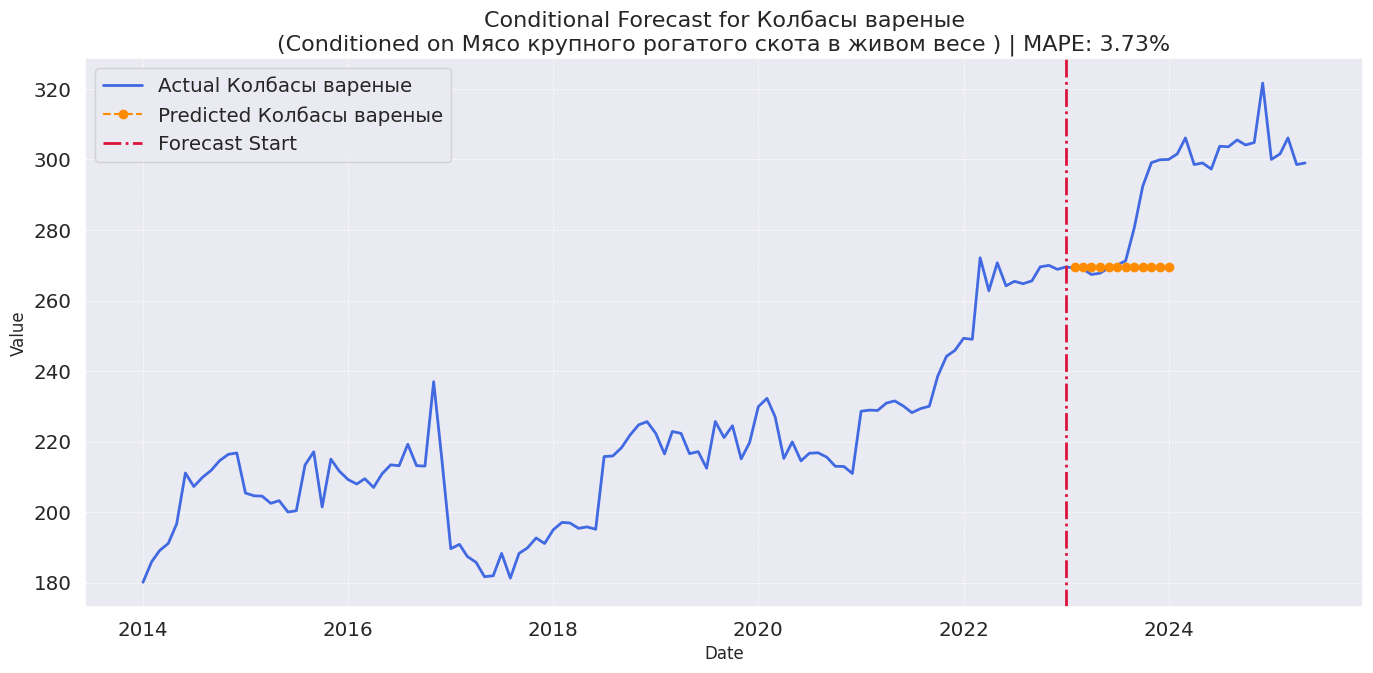

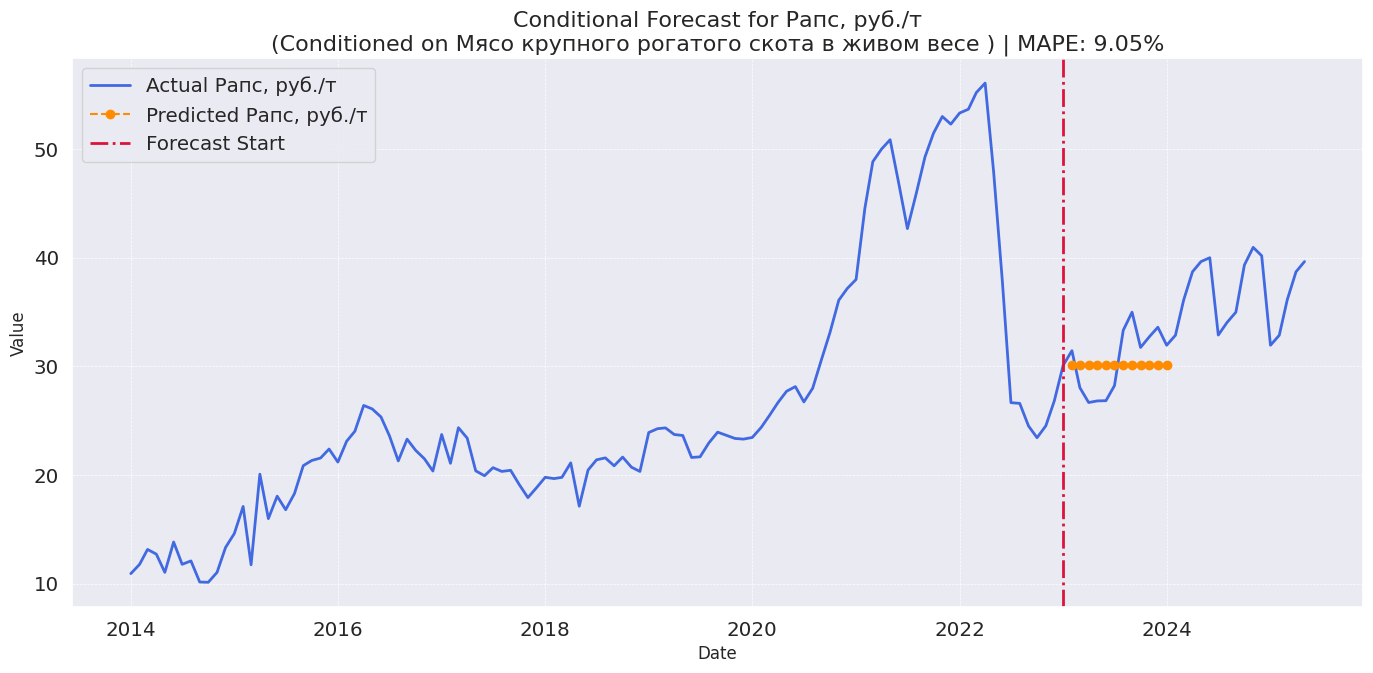

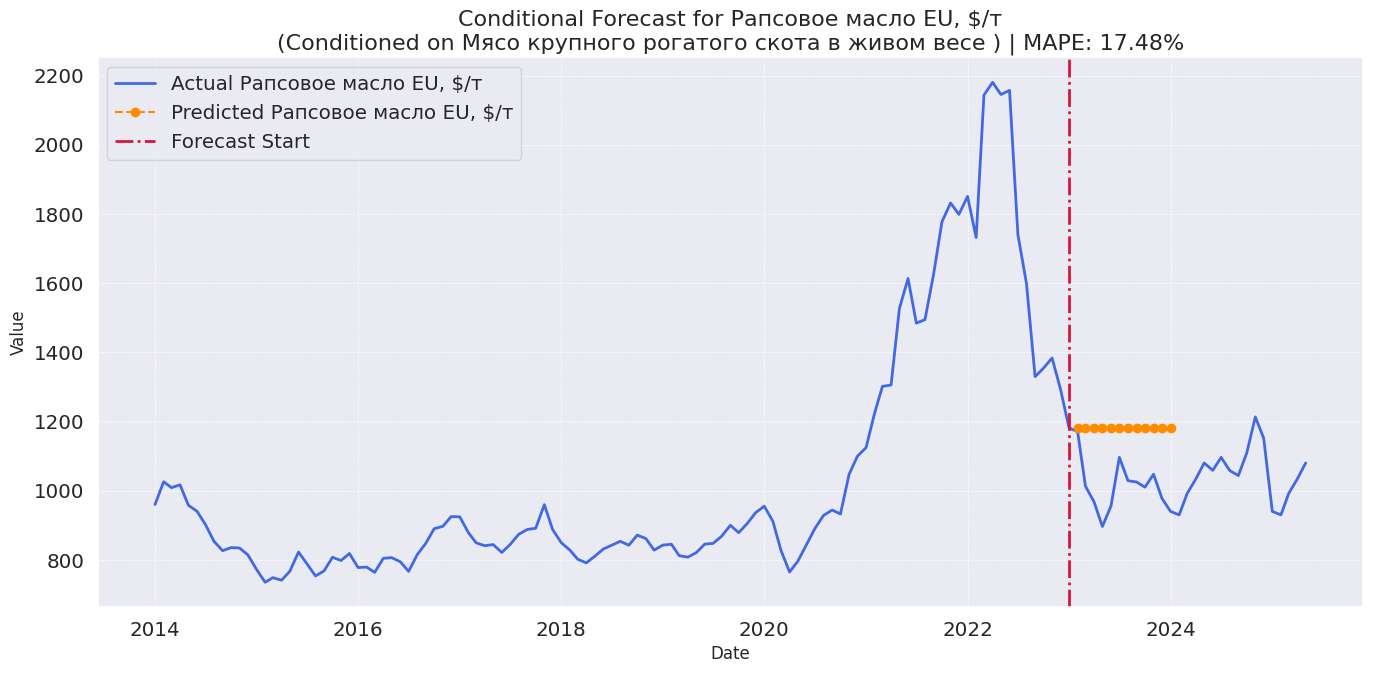

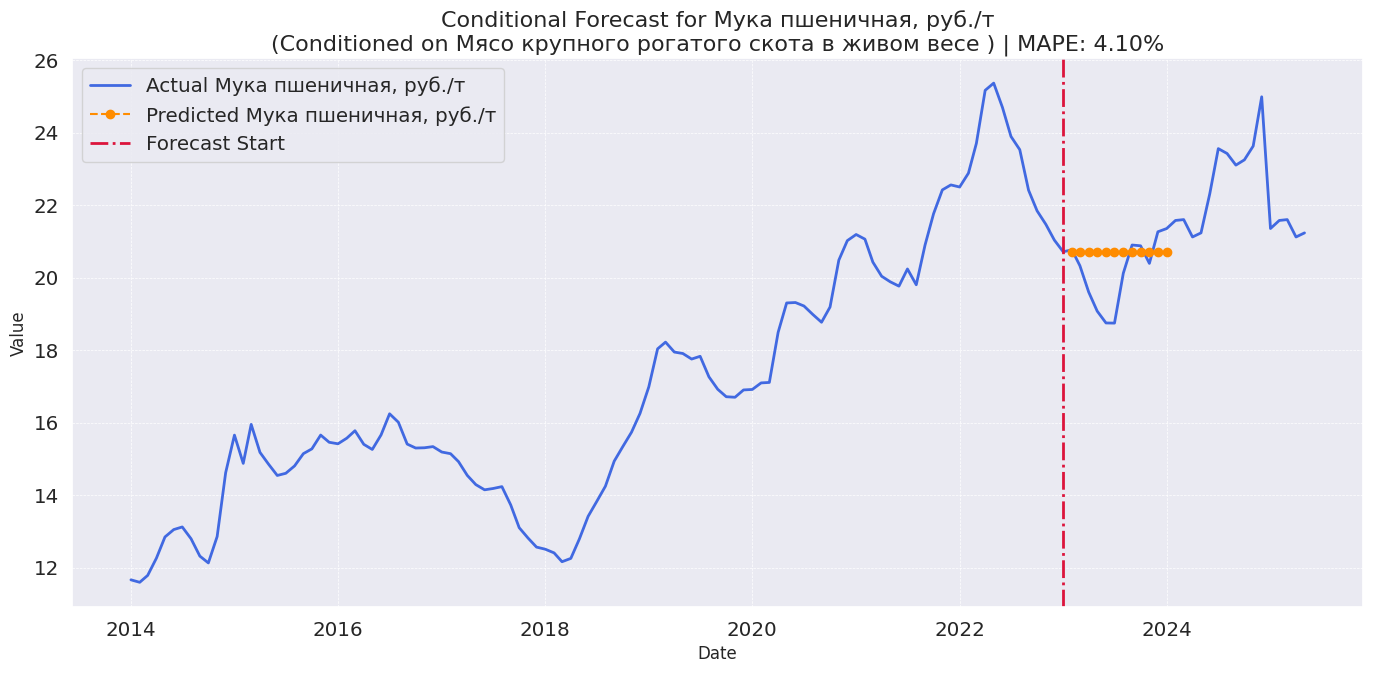

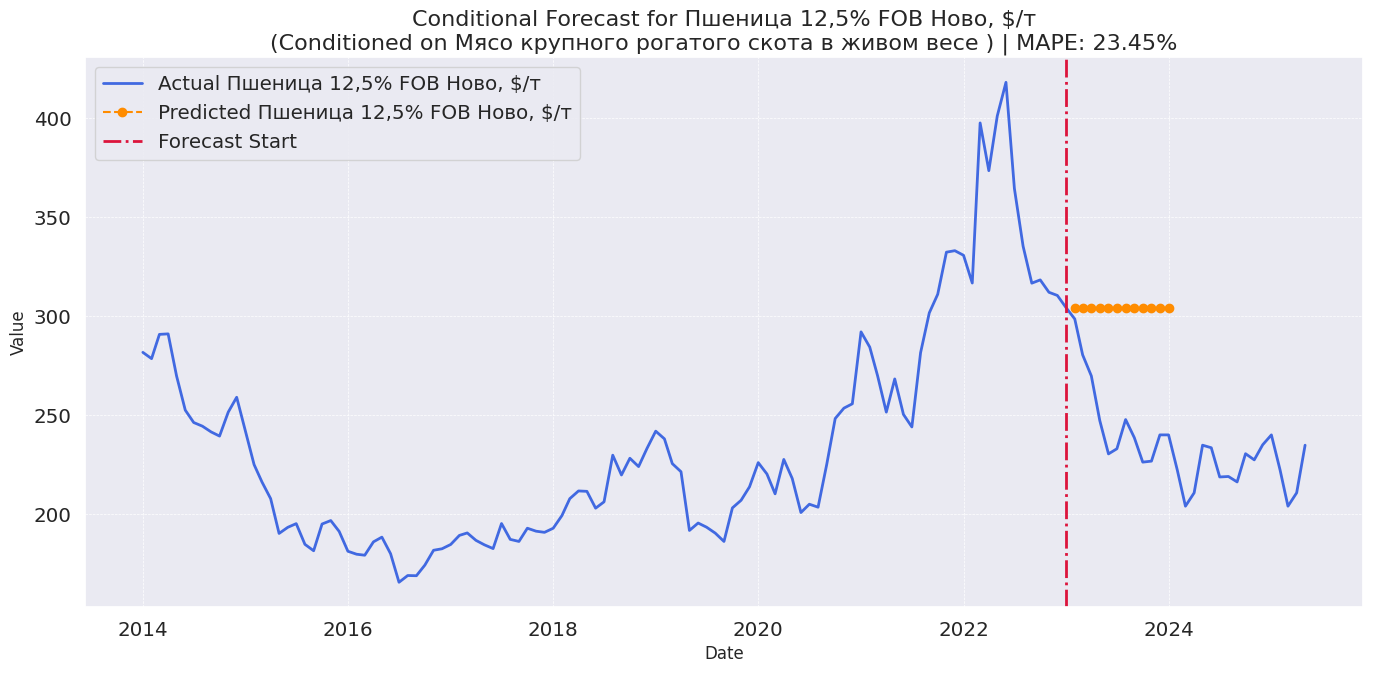

In [95]:
plot_model_pred(
        model_class=DummyConditionalModel,
        df=df,
        model_params={'smoothing_factor': 0.1},
        conditioning_col=df.columns[4], # Example: condition on Wheat
        horizon=12,
        cutoff_date='2023-01-01' # Example: train up to end of Jan 2025
    )

### Unconditional (Simple) VAR

In [99]:
validation_params = {
    "model_class": VARModel,
    "df": df,
    "horizon": 12,
    "stride": 2,
    "start_window": 60,
    "target_columns": df.columns[1:5],
    "model_params": {'maxlags': 4},
}

In [100]:
cv_errors = cross_validate_model(**validation_params)
print(calc_avg_error(cv_errors))

{}


/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: Valu

In [ ]:
matrix_params = {
    "model_class": VARModel,
    "df": df,
    "horizon": 12,
    "stride": 12,
    "start_window": 60,
    "model_params": {"maxlags": 12},
}

In [ ]:
final_matrix = build_error_matrix(**matrix_params)
plot_error_matrix(final_matrix)